# **MODELADO**

## Setup: imports y carga de checkpoints

Carga `af_modelo` y `dataset_original_copy` ya procesados (generados por `feature_engineering/02_preprocesamiento.py` y `data/02_carga_dataset_desglosado.py`) en vez de re-ejecutar todo el pipeline de datos/EDA/feature engineering.

**Importante:** correr este notebook con el directorio raiz del repositorio como working directory (no `modeling/`), igual que el resto de los scripts.

In [1]:
import os
# El kernel de Jupyter en VS Code por defecto usa la carpeta del .ipynb
# (modeling/) como working directory, a diferencia de como VS Code corre
# los .py (que usan la raiz del repo). Nos subimos un nivel si hace falta
# para que las rutas relativas (data/processed/..., etc.) sean consistentes
# con el resto del pipeline.
if os.path.basename(os.getcwd()) == 'modeling':
    os.chdir('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
import plotly.graph_objects as go
import plotly.express as px

af_modelo = pd.read_pickle('data/processed/af_modelo.pkl')
dataset_original_copy = pd.read_pickle('data/processed/dataset_original_copy.pkl')

C:\Users\Becario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
af_modelo.isna().sum()
datos = af_modelo[
    (af_modelo['linea']=='linea 2') &
    (af_modelo['estacion']=='cuatro caminos')
]

serie = datos['afluencia'].dropna().sort_index() 

serie = datos['afluencia'].dropna() 
serie = serie.sort_index()

In [3]:
# División 80-20
train_size = int(len(serie) * 0.85)

train = serie[:train_size]
test = serie[train_size:]

print(f"Train: {len(train)}")
print(f"Test: {len(test)}")

Train: 904
Test: 160


## PROPHET

In [4]:
# Prophet necesita formato ds/y
df_prophet = pd.DataFrame({
    'ds': serie.index,
    'y': serie.values
})

# División temporal idéntica
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

# Entrena
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.03
)
modelo_prophet.add_country_holidays(country_name='MX')

modelo_prophet.fit(train_prophet)

# Predecir SOLO test
future = test_prophet[['ds']]

forecast = modelo_prophet.predict(future)

pred_prophet = forecast['yhat'].values

14:30:57 - cmdstanpy - INFO - Chain [1] start processing
14:30:57 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
def metricas_series_tiempo(y_real, y_pred):
    # MAE
    # Error absoluto promedio
    mae = mean_absolute_error(y_real, y_pred)

    # MSE
    # Error cuadrático medio
    mse = mean_squared_error(y_real, y_pred)

    # RMSE
    # Penaliza errores grandes
    rmse = np.sqrt(mse)

    # MAPE
    # Error porcentual medio
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    # SMAPE
    # Más estable que MAPE
    smape = np.mean(2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred))) * 100

    medae = median_absolute_error(y_real, y_pred)

    # R cuadrada
    r2 = r2_score(y_real, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "SMAPE": smape,
        "R2": r2,
        "MedAE": medae
        }

metricas_prophet = metricas_series_tiempo(test, pred_prophet)

print("\n========== PROPHET ==========\n")

for k, v in metricas_prophet.items():
    if k in ["MAPE", "SMAPE"]:
        print(f"{k:<10}: {v:.2f}%")
    else:
        print(f"{k:<10}: {v:.2f}")


========== PROPHET ==========

MAE       : 7991.73
MSE       : 118800635.36
RMSE      : 10899.57
MAPE      : 10.43%
SMAPE     : 9.30%
R2        : 0.66
MedAE     : 6762.75


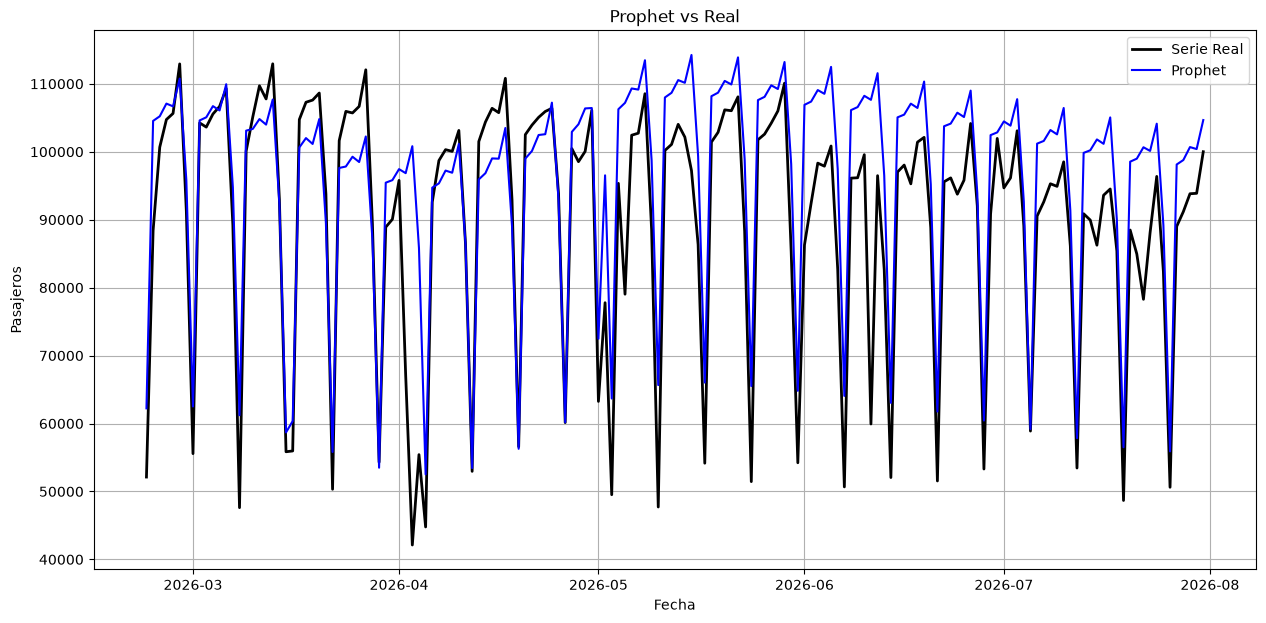

In [6]:
plt.figure(figsize=(15,7))

plt.plot(test.index,
    test.values,
    label='Serie Real',
    color='black',
    linewidth=2)

plt.plot(test.index,
    pred_prophet,
    label='Prophet',
    color='blue')

plt.title('Prophet vs Real')
plt.ylabel('Pasajeros')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True)
plt.show()

## Predicción completa (entrenamiento + prueba)

El modelo se entrenó solo con `train_prophet`; al predecir sobre `df_prophet` completo se obtiene el ajuste dentro de la muestra de entrenamiento y el pronóstico genuino (fuera de muestra) sobre el período de prueba, todo en una sola gráfica.

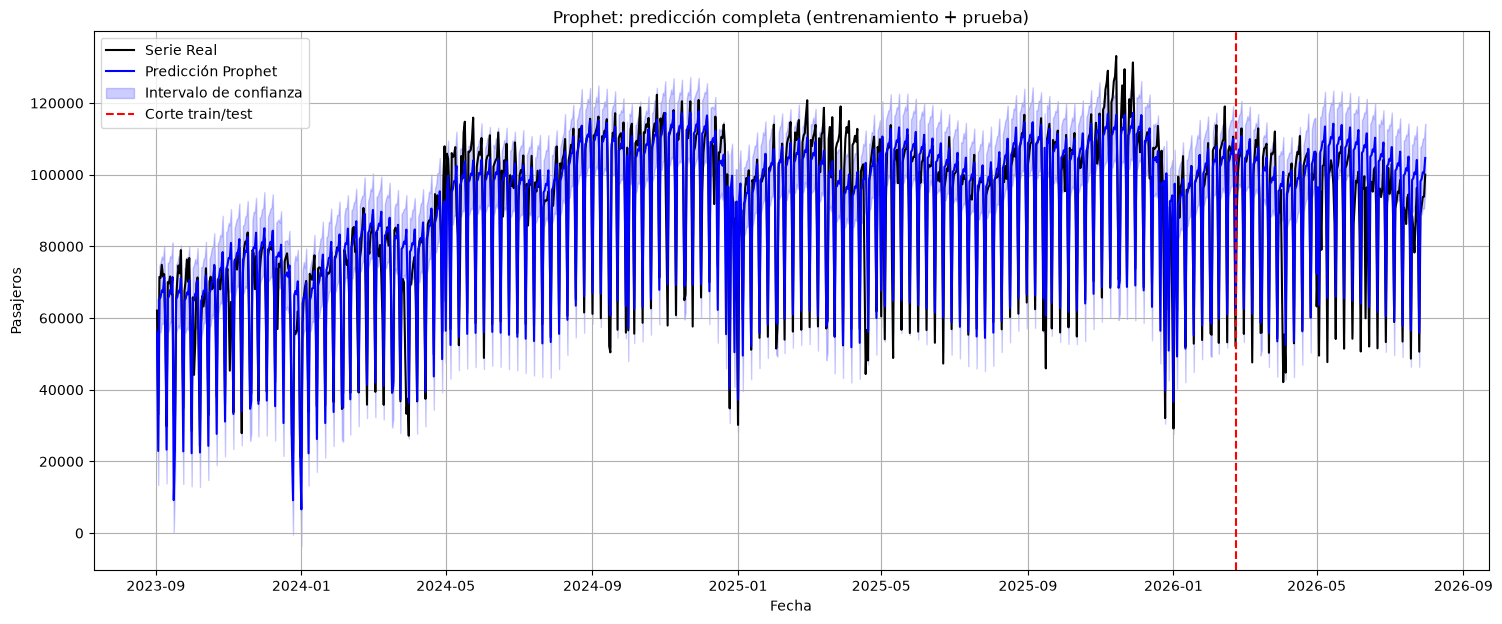

In [7]:
forecast_completo = modelo_prophet.predict(df_prophet[['ds']])

plt.figure(figsize=(18,7))

plt.plot(df_prophet['ds'], df_prophet['y'], label='Serie Real', color='black', linewidth=1.5)
plt.plot(forecast_completo['ds'], forecast_completo['yhat'], label='Predicción Prophet', color='blue', linewidth=1.5)
plt.fill_between(
    forecast_completo['ds'],
    forecast_completo['yhat_lower'],
    forecast_completo['yhat_upper'],
    alpha=0.2,
    color='blue',
    label='Intervalo de confianza'
)
plt.axvline(
    df_prophet['ds'].iloc[train_size],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Corte train/test'
)

plt.title('Prophet: predicción completa (entrenamiento + prueba)')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.show()

## Validación cruzada (cross-validation)

Un solo corte train/test (85-15) da una sola muestra de error; puede salir optimista o pesimista según qué tan típico sea ese tramo de prueba en particular. La validación cruzada de Prophet corta la serie en varios puntos ("cutoffs") y mide el error en cada horizonte de pronóstico, dando una evaluación mucho más robusta de qué tan bien generaliza el modelo. Aquí se reentrena sobre toda la serie (`df_prophet` completo, no solo `train_prophet`) porque la validación cruzada ya hace sus propios cortes internos.

In [8]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

modelo_prophet_completo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.03
)
modelo_prophet_completo.add_country_holidays(country_name='MX')
modelo_prophet_completo.fit(df_prophet)

# Parametros de CV adaptados a la longitud real de la serie: horizonte de
# pronostico ~15% del total (entre 30 y 90 dias), cortes cada medio
# horizonte, y al menos 180 dias (o lo que quede) de entrenamiento inicial.
total_dias = (df_prophet['ds'].max() - df_prophet['ds'].min()).days
horizon_dias = max(30, min(90, int(total_dias * 0.15)))
periodo_dias = max(15, int(horizon_dias / 2))
inicial_dias = max(180, total_dias - horizon_dias * 4)

print(f"Total de dias en la serie: {total_dias}")
print(f"CV -> initial: {inicial_dias}d, period: {periodo_dias}d, horizon: {horizon_dias}d")

df_cv = cross_validation(
    modelo_prophet_completo,
    initial=f'{inicial_dias} days',
    period=f'{periodo_dias} days',
    horizon=f'{horizon_dias} days'
)

df_metricas_cv = performance_metrics(df_cv)
print(df_metricas_cv[['horizon', 'mae', 'rmse', 'mape', 'coverage']].head(10))

14:31:02 - cmdstanpy - INFO - Chain [1] start processing
14:31:02 - cmdstanpy - INFO - Chain [1] done processing


Total de dias en la serie: 1063
CV -> initial: 703d, period: 45d, horizon: 90d


  0%|          | 0/7 [00:00<?, ?it/s]14:31:03 - cmdstanpy - INFO - Chain [1] start processing
14:31:03 - cmdstanpy - INFO - Chain [1] done processing
 14%|█▍        | 1/7 [00:00<00:05,  1.15it/s]14:31:04 - cmdstanpy - INFO - Chain [1] start processing
14:31:04 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 2/7 [00:01<00:04,  1.00it/s]14:31:05 - cmdstanpy - INFO - Chain [1] start processing
14:31:05 - cmdstanpy - INFO - Chain [1] done processing
 43%|████▎     | 3/7 [00:02<00:04,  1.00s/it]14:31:06 - cmdstanpy - INFO - Chain [1] start processing
14:31:06 - cmdstanpy - INFO - Chain [1] done processing
 57%|█████▋    | 4/7 [00:04<00:03,  1.02s/it]14:31:07 - cmdstanpy - INFO - Chain [1] start processing
14:31:07 - cmdstanpy - INFO - Chain [1] done processing
 71%|███████▏  | 5/7 [00:05<00:02,  1.07s/it]14:31:08 - cmdstanpy - INFO - Chain [1] start processing
14:31:08 - cmdstanpy - INFO - Chain [1] done processing
 86%|████████▌ | 6/7 [00:06<00:01,  1.16s/it]14:31:09 - cmds

  horizon          mae          rmse      mape  coverage
0  9 days  8262.361075  10837.409903  0.093499  0.714286
1 10 days  8375.674973  11053.422693  0.092693  0.714286
2 11 days  8351.833080  11155.220699  0.092134  0.730159
3 12 days  7598.580965  10051.486065  0.083437  0.777778
4 13 days  7952.674996  10802.586198  0.091378  0.746032
5 14 days  8093.256638  10864.119138  0.099397  0.714286
6 15 days  8521.381693  11183.640047  0.105163  0.682540
7 16 days  9116.346741  13271.055229  0.119143  0.682540
8 17 days  9143.561933  13450.601615  0.121324  0.666667
9 18 days  9187.830984  13466.683296  0.123021  0.666667


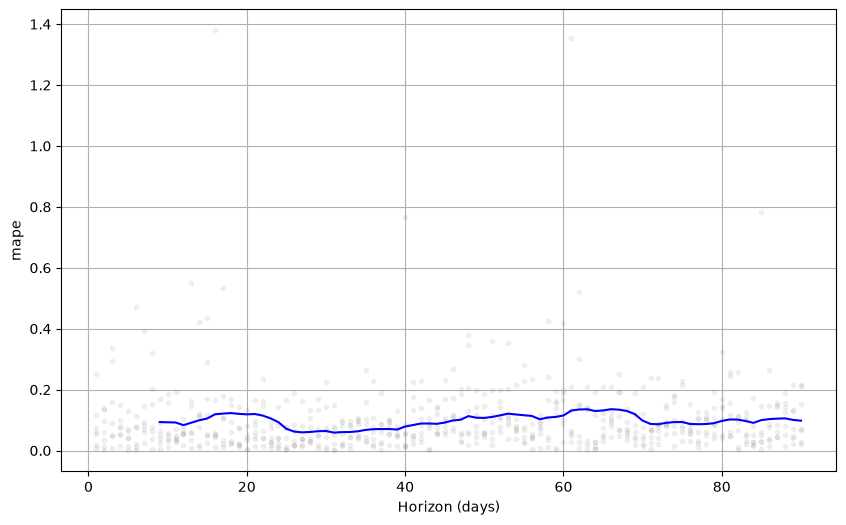

In [9]:
fig_cv = plot_cross_validation_metric(df_cv, metric='mape')
plt.show()

# **Detección de anomalías**

In [10]:
# Guardar predicciones dentro de test_prophet
test_prophet['yhat'] = forecast['yhat'].values
test_prophet['yhat_lower'] = forecast['yhat_lower'].values
test_prophet['yhat_upper'] = forecast['yhat_upper'].values

C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\4090808746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_prophet['yhat'] = forecast['yhat'].values
C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\4090808746.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_prophet['yhat_lower'] = forecast['yhat_lower'].values
C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\4090808746.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\1213579155.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_prophet['residuo'] = (test_prophet['y'] - test_prophet['yhat'])
C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\1213579155.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_prophet['anomalia'] = ((test_prophet['residuo'] > limite_superior) | (test_prophet['residuo'] < limite_inferior))


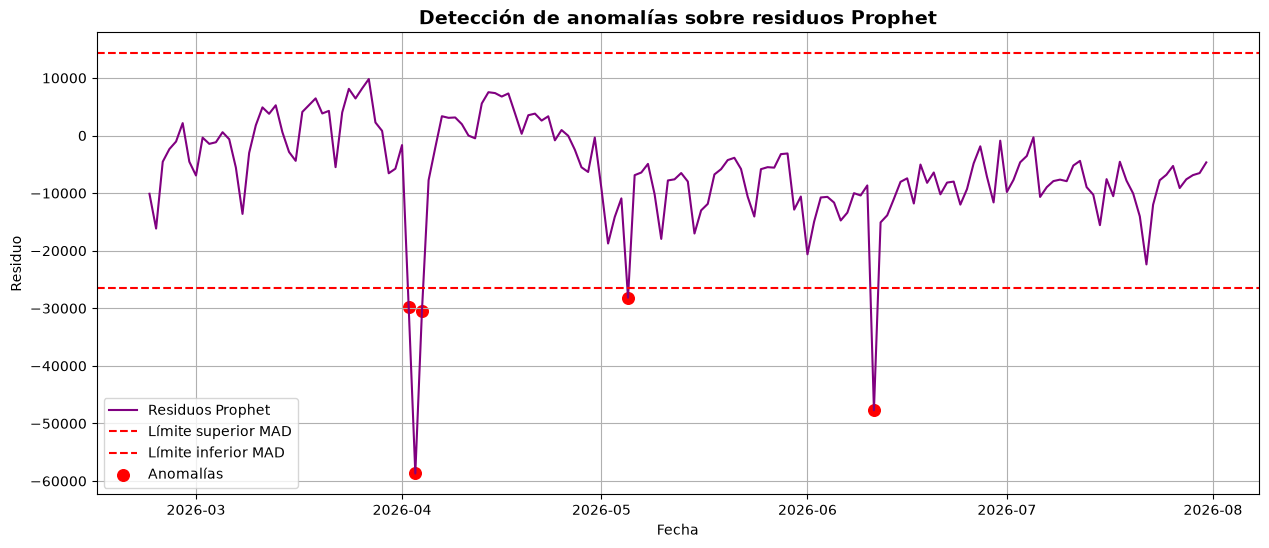

Total anomalías detectadas: 5


In [11]:
# RESIDUOS DE PROPHET

test_prophet['residuo'] = (test_prophet['y'] - test_prophet['yhat'])

# MAD ROBUSTO SOBRE RESIDUOS
mediana_residuos = np.median(test_prophet['residuo'])

mad_residuos = np.median(np.abs(test_prophet['residuo'] - mediana_residuos))

sigma_residuos = mad_residuos * 1.4826
factor_prophet = 3

limite_superior = (mediana_residuos + factor_prophet * sigma_residuos)

limite_inferior = (mediana_residuos - factor_prophet * sigma_residuos)

# DETECCIÓN DE ANOMALÍAS

test_prophet['anomalia'] = ((test_prophet['residuo'] > limite_superior) | (test_prophet['residuo'] < limite_inferior))

# GRÁFICA RESIDUOS + MAD
plt.figure(figsize=(15,6))

plt.plot(test_prophet['ds'],
    test_prophet['residuo'],
    label='Residuos Prophet',
    color='purple')

plt.axhline(limite_superior,
    color='red',
    linestyle='--',
    label='Límite superior MAD')

plt.axhline(limite_inferior,
    color='red',
    linestyle='--',
    label='Límite inferior MAD')

plt.scatter(test_prophet.loc[test_prophet['anomalia'], 'ds'],
    test_prophet.loc[test_prophet['anomalia'], 'residuo'],
    color='red',
    s=70,
    label='Anomalías')

plt.title('Detección de anomalías sobre residuos Prophet', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.legend()
plt.grid(True)
plt.show()


print(f"Total anomalías detectadas: {test_prophet['anomalia'].sum()}")

La idea sería:

Prophet modela: tendencia, estacionalidad semanal,patrones temporales.
Luego analizas los residuos:

residuo=yreal −ypredicho
	​

Sobre esos residuos aplicas MAD robusto.

Eso es muchísimo mejor que aplicar MAD directamente sobre la serie original, porque la serie del metro no es estacionaria:

tiene tendencia, días de semana vs domingo,
variaciones normales del sistema. Entonces, si aplicas MAD directamente a la serie:

muchos domingos parecen “anómalos” aunque son normales, cambios estacionales normales generan falsos positivos.

En cambio, sobre residuos:

Prophet ya explica el comportamiento esperado y MAD detecta únicamente desviaciones inesperadas.

C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\3390378518.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_prophet['anomalia_mad'] = (
C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\3390378518.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_prophet['anomalia_ic'] = (
C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\3390378518.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

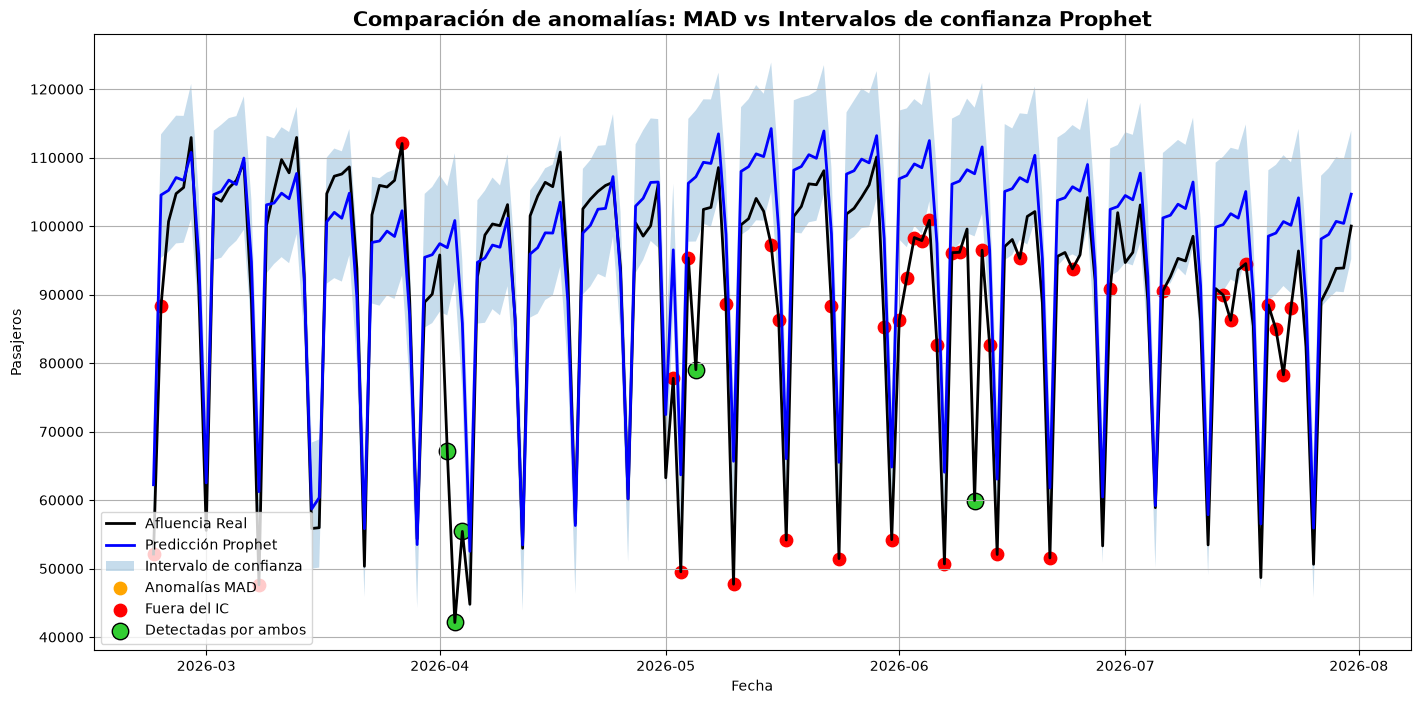


--- RESUMEN DE DETECCIÓN ---

Anomalías MAD: 5
Anomalías IC Prophet: 45
Coincidencias entre ambos: 5


In [12]:
# ANOMALÍAS POR MAD EN RESIDUOS

test_prophet['anomalia_mad'] = (
    (test_prophet['residuo'] > limite_superior) |
    (test_prophet['residuo'] < limite_inferior))

test_prophet['anomalia_ic'] = (
    (test_prophet['y'] < test_prophet['yhat_lower']) |
    (test_prophet['y'] > test_prophet['yhat_upper']))

test_prophet['anomalia_ambos'] = (
    test_prophet['anomalia_mad'] &
    test_prophet['anomalia_ic'])

plt.figure(figsize=(17,8))
# Serie real
plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Afluencia Real',
    color='black',
    linewidth=2
)

# Predicción Prophet
plt.plot(
    test_prophet['ds'],
    test_prophet['yhat'],
    label='Predicción Prophet',
    color='blue',
    linewidth=2
)

plt.fill_between(
    test_prophet['ds'],
    test_prophet['yhat_lower'],
    test_prophet['yhat_upper'],
    alpha=0.25,
    label='Intervalo de confianza'
)

plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_mad'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_mad'],
        'y'
    ],
    color='orange',
    s=80,
    label='Anomalías MAD'
)


plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_ic'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_ic'],
        'y'
    ],
    color='red',
    s=80,
    label='Fuera del IC'
)


plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_ambos'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_ambos'],
        'y'
    ],
    color='limegreen',
    edgecolors='black',
    s=140,
    label='Detectadas por ambos'
)

plt.title(
    'Comparación de anomalías: MAD vs Intervalos de confianza Prophet',
    fontsize=15,
    fontweight='bold'
)
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.show()


print("\n--- RESUMEN DE DETECCIÓN ---\n")
print(f"Anomalías MAD: {test_prophet['anomalia_mad'].sum()}")
print(f"Anomalías IC Prophet: {test_prophet['anomalia_ic'].sum()}")
print(f"Coincidencias entre ambos: {test_prophet['anomalia_ambos'].sum()}")

In [13]:
import numpy as np
import pandas as pd

# 1. Se parte nuevamente del dataset limpio (agrupado por dia)
df_limpio = dataset_original_copy.groupby(['fecha', 'linea', 'estacion'])['afluencia'].sum().reset_index()
#copia de seguridad del dataset limpio
df_limpio_copy = df_limpio.copy()
# 2. Agrupamos logicamente para calculos moviles
agg = df_limpio.groupby(['linea', 'estacion'])['afluencia']

# 3. Calculo Media y Desviacion Estandar Movil (Ventana 7 dias, con shift para no ver el futuro)
df_limpio['media_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
df_limpio['std_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).std().shift(1))

# 4. Recalculo de Z-Score Clasico
df_limpio['zscore_movil'] = (df_limpio['afluencia'] - df_limpio['media_movil']) / df_limpio['std_movil']

# 5. Generamos la bandera booleana de anomalia (enfocada en caidas)
df_limpio['anomalia_z'] = df_limpio['zscore_movil'] < -3

# --- Calcular MAD ---
def rolling_mad(x):
    mediana = np.median(x)
    return np.median(np.abs(x - mediana))

df_limpio['mediana_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).median().shift(1))
df_limpio['mad_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).apply(rolling_mad).shift(1))
df_limpio['zscore_robusto'] = (df_limpio['afluencia'] - df_limpio['mediana_movil']) / (df_limpio['mad_movil'] * 1.4826)


A continuación se procesan todas las estaciones, genera las predicciones de prophet y MAD creando una clasificación de las anomalías:

CRÍTICA (Consenso Absoluto)
¿Qué significa?: MAD detectó que hoy hubo un desplome severo de gente comparado con los últimos 7 días Y Prophet confirmó que ese desplome es matemáticamente imposible para esta época del año.
Interpretación Operativa: Es un Incidente Mayor casi seguro. Hubo un cierre de estación, un corte de energía prolongado o un tren descarrilado.

ALTA (Desviación Estacional)
¿Qué significa?: MAD dijo "todo normal" (la afluencia se parece a la de ayer), PERO Prophet detectó que los números están muy por debajo de lo que dicta la historia.
Interpretación Operativa: Es un Fallo Crónico o Degradación de Servicio. Por ejemplo: si una escalera eléctrica gigante lleva rota toda la semana, la gente empieza a evitar esa estación paulatinamente. MAD no lo nota porque la caída es lenta, pero Prophet sabe que ahí debería haber un 20% más de pasajeros.

MEDIA (Shock Local / Ruido)
¿Qué significa?: MAD detectó una caída brusca respecto a ayer, PERO Prophet dice que "es normal, siempre pasa en estas fechas".
Interpretación Operativa: Suele ser comportamiento natural de la ciudad. Por ejemplo, el jueves de Semana Santa. MAD ve que ayer miércoles estaba lleno y hoy vacío, por lo que entra en pánico. Prophet sabe que es festividad y desestima la alerta.

# **MODELO PARA LAS 195 SERIES DE TIEMPO**

In [14]:
import re
import unicodedata

COLORES_PRIORIDAD = {
    'CRÍTICA (Consenso)': '#8B0000',
    'ALTA (Solo Prophet)': '#FF8C00',
    'MEDIA (Solo MAD)': '#C9B800'
}

def _slug(texto):
    # 'boulevard puerto aéreo' -> 'boulevard_puerto_aereo' (nombre de archivo seguro)
    t = unicodedata.normalize('NFKD', str(texto)).encode('ascii', 'ignore').decode()
    return re.sub(r'[^a-z0-9]+', '_', t.lower()).strip('_')

def _dibujar_pronostico(ax, df_hist, df_futuro, tam_punto, grosor):
    ax.plot(df_hist['ds'], df_hist['afluencia'], color='black', linewidth=grosor, label='Afluencia real')
    ax.plot(df_hist['ds'], df_hist['yhat'], color='blue', linewidth=grosor, label='Prophet (ajuste)')
    ax.fill_between(df_hist['ds'], df_hist['yhat_lower'], df_hist['yhat_upper'],
                    color='blue', alpha=0.15, label='Intervalo de confianza')

    for prioridad, color in COLORES_PRIORIDAD.items():
        sel = df_hist[df_hist['prioridad_auditoria'] == prioridad]
        if len(sel):
            ax.scatter(sel['ds'], sel['afluencia'], s=tam_punto, color=color, zorder=3,
                       label=f'{prioridad} ({len(sel)})')

    if len(df_futuro):
        ax.plot(df_futuro['ds'], df_futuro['yhat'], color='green', linestyle='--', linewidth=1.5,
                label=f'Pronóstico próximos {len(df_futuro)} días')
        ax.fill_between(df_futuro['ds'], df_futuro['yhat_lower'], df_futuro['yhat_upper'],
                        color='green', alpha=0.2)
        ax.axvline(df_hist['ds'].max(), color='gray', linestyle=':', linewidth=1)

    ax.set_ylabel('Afluencia diaria (pasajeros)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.grid(True, alpha=0.3)

def graficar_pronostico_serie(linea, estacion, df_hist, df_futuro, carpeta, dias_zoom=90):
    """Guarda una grafica por serie: arriba todo el historico, abajo zoom a los ultimos dias + pronostico."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    _dibujar_pronostico(ax1, df_hist, df_futuro, tam_punto=8, grosor=0.7)
    ax1.set_title(f'Pronóstico Prophet: {linea} - {estacion}', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=8, ncol=2)

    zoom = df_hist[df_hist['ds'] > df_hist['ds'].max() - pd.Timedelta(days=dias_zoom)]
    _dibujar_pronostico(ax2, zoom, df_futuro, tam_punto=28, grosor=1.3)
    ax2.set_title(f'Zoom: últimos {dias_zoom} días + pronóstico', fontsize=11)
    ax2.set_xlabel('Fecha')

    ruta = os.path.join(carpeta, _slug(linea), f'{_slug(estacion)}.png')
    os.makedirs(os.path.dirname(ruta), exist_ok=True)
    fig.tight_layout()
    fig.savefig(ruta, dpi=100, bbox_inches='tight')
    plt.close(fig)
    return ruta

def motor_auditoria_consenso_mad_bidireccional(df_input, carpeta_graficas='modeling/img_pronosticos', dias_futuro=30):
    # carpeta_graficas=None desactiva las graficas; dias_futuro=0 quita el pronostico a futuro
    resultados_master = []
    series_prophet = []   # pronostico completo (historico + futuro) de cada serie, para el modelo de riesgo
    grupos = df_input.groupby(['linea', 'estacion'])
    total = len(grupos)

    print(f"Iniciando auditoría masiva bidireccional para {total} estaciones...")

    for i, ((linea, estacion), df_grupo) in enumerate(grupos, 1):
        try:
            df_p = df_grupo.copy()
            if 'fecha' not in df_p.columns: df_p = df_p.reset_index()
            df_prophet = df_p[['fecha', 'afluencia']].rename(columns={'fecha': 'ds', 'afluencia': 'y'})

            # No se entrena con dias de afluencia=0 (cierres de estacion): sesgarian
            # la tendencia/estacionalidad hacia abajo. Se predice sobre TODOS los
            # dias (incluidos los ceros) para que un cierre real siga detectandose
            # como anomalia al comparar contra lo que Prophet esperaba.
            df_prophet_train = df_prophet[df_prophet['y'] > 0]

            m = Prophet(yearly_seasonality=True, weekly_seasonality=True, changepoint_prior_scale=0.03)
            m.add_country_holidays(country_name='MX')
            m.fit(df_prophet_train)

            # Una sola prediccion sobre historico + dias futuros; el tramo historico
            # es el mismo de siempre, el futuro solo alimenta la grafica de pronostico.
            ds_hist = df_prophet['ds']
            ds_futuro = pd.date_range(ds_hist.max() + pd.Timedelta(days=1), periods=dias_futuro, freq='D')
            forecast_total = m.predict(pd.DataFrame({'ds': list(ds_hist) + list(ds_futuro)}))
            forecast = forecast_total.iloc[:len(ds_hist)]
            forecast_futuro = forecast_total.iloc[len(ds_hist):]

            df_merge = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
                df_p[['fecha', 'afluencia', 'zscore_robusto']],
                left_on='ds', right_on='fecha'
            )

            # --- Detección en ambas direcciones (Alza y Baja) ---
            df_merge['det_prophet'] = (df_merge['afluencia'] < df_merge['yhat_lower']) | (df_merge['afluencia'] > df_merge['yhat_upper'])
            df_merge['det_mad'] = (df_merge['zscore_robusto'] < -3) | (df_merge['zscore_robusto'] > 3)

            # Reglas de Consenso
            conditions = [
                (df_merge['det_prophet'] & df_merge['det_mad']),
                (df_merge['det_prophet'] & ~df_merge['det_mad']),
                (~df_merge['det_prophet'] & df_merge['det_mad'])
            ]
            prioridades = ['CRÍTICA (Consenso)', 'ALTA (Solo Prophet)', 'MEDIA (Solo MAD)']
            df_merge['prioridad_auditoria'] = np.select(conditions, prioridades, default='Normal')

            df_merge['linea'] = linea
            df_merge['estacion'] = estacion
            df_merge['impacto_pasajeros'] = round(df_merge['afluencia'] - df_merge['yhat'], 0)

            # --- Etiquetado de la dirección de la anomalía ---
            df_merge['direccion_anomalia'] = np.where(df_merge['impacto_pasajeros'] > 0, 'Alza (Pico atípico)', 'Baja (Caída atípica)')

            # Grafica de pronostico de la serie (un fallo al graficar no descarta las anomalias)
            if carpeta_graficas:
                try:
                    graficar_pronostico_serie(linea, estacion, df_merge, forecast_futuro, carpeta_graficas)
                except Exception as e_graf:
                    print(f"Aviso: no se pudo graficar {estacion} ({linea}): {e_graf}")

            # Guardar el pronostico de Prophet de la serie (todos los dias, con su etiqueta; futuros con es_futuro=True)
            cols_fc = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
            serie_completa = pd.concat([
                df_merge[cols_fc + ['afluencia', 'zscore_robusto', 'prioridad_auditoria']].assign(es_futuro=False),
                forecast_futuro[cols_fc].assign(es_futuro=True)
            ], ignore_index=True)
            # Componentes de Prophet: efecto de festivos (MX), estacionalidad anual y tendencia (en pasajeros)
            serie_completa = serie_completa.merge(forecast_total[['ds', 'holidays', 'yearly', 'trend']], on='ds', how='left')
            serie_completa['linea'] = linea
            serie_completa['estacion'] = estacion
            series_prophet.append(serie_completa)
            
            # Guardar solo anomalías
            anomalias = df_merge[df_merge['prioridad_auditoria'] != 'Normal'].copy()
            resultados_master.append(anomalias)

            if i % 10 == 0: print(f"Progreso: {i}/{total} estaciones procesadas.")

        except Exception as e:
            print(f"Error en {estacion} ({linea}): {e}")
            continue

    df_final = pd.concat(resultados_master, ignore_index=True)
    df_series = pd.concat(series_prophet, ignore_index=True)
    return df_final, df_series

# Ejecución
# (deja una grafica por serie en modeling/img_pronosticos/<linea>/<estacion>.png)
master_auditoria, series_prophet = motor_auditoria_consenso_mad_bidireccional(df_limpio)

master_auditoria.to_csv('master_auditoria_consenso_MAD.csv', index=False)
master_auditoria.to_excel('master_auditoria_consenso_MAD.xlsx', index=False)

# Pronosticos de Prophet de todas las series (historico + proximos dias): insumo del modelo de riesgo (RF/XGBoost)
os.makedirs('data/processed', exist_ok=True)
series_prophet.to_pickle('data/processed/prophet_series.pkl')

Iniciando auditoría masiva bidireccional para 196 estaciones...


14:34:10 - cmdstanpy - INFO - Chain [1] start processing
14:34:11 - cmdstanpy - INFO - Chain [1] done processing
14:34:14 - cmdstanpy - INFO - Chain [1] start processing
14:34:14 - cmdstanpy - INFO - Chain [1] done processing
14:34:17 - cmdstanpy - INFO - Chain [1] start processing
14:34:17 - cmdstanpy - INFO - Chain [1] done processing
14:34:20 - cmdstanpy - INFO - Chain [1] start processing
14:34:20 - cmdstanpy - INFO - Chain [1] done processing
14:34:24 - cmdstanpy - INFO - Chain [1] start processing
14:34:24 - cmdstanpy - INFO - Chain [1] done processing
14:34:27 - cmdstanpy - INFO - Chain [1] start processing
14:34:27 - cmdstanpy - INFO - Chain [1] done processing
14:34:30 - cmdstanpy - INFO - Chain [1] start processing
14:34:31 - cmdstanpy - INFO - Chain [1] done processing
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet

Progreso: 10/196 estaciones procesadas.


14:34:42 - cmdstanpy - INFO - Chain [1] start processing
14:34:42 - cmdstanpy - INFO - Chain [1] done processing
14:34:45 - cmdstanpy - INFO - Chain [1] start processing
14:34:45 - cmdstanpy - INFO - Chain [1] done processing
14:34:47 - cmdstanpy - INFO - Chain [1] start processing
14:34:47 - cmdstanpy - INFO - Chain [1] done processing
14:34:50 - cmdstanpy - INFO - Chain [1] start processing
14:34:50 - cmdstanpy - INFO - Chain [1] done processing
14:34:53 - cmdstanpy - INFO - Chain [1] start processing
14:34:54 - cmdstanpy - INFO - Chain [1] done processing
14:34:56 - cmdstanpy - INFO - Chain [1] start processing
14:34:57 - cmdstanpy - INFO - Chain [1] done processing
14:34:59 - cmdstanpy - INFO - Chain [1] start processing
14:35:00 - cmdstanpy - INFO - Chain [1] done processing
14:35:02 - cmdstanpy - INFO - Chain [1] start processing
14:35:03 - cmdstanpy - INFO - Chain [1] done processing
14:35:05 - cmdstanpy - INFO - Chain [1] start processing
14:35:05 - cmdstanpy - INFO - Chain [1]

Progreso: 20/196 estaciones procesadas.


...

14:43:27 - cmdstanpy - INFO - Chain [1] start processing
14:43:27 - cmdstanpy - INFO - Chain [1] done processing
14:43:30 - cmdstanpy - INFO - Chain [1] start processing
14:43:30 - cmdstanpy - INFO - Chain [1] done processing
14:43:33 - cmdstanpy - INFO - Chain [1] start processing
14:43:34 - cmdstanpy - INFO - Chain [1] done processing
14:43:36 - cmdstanpy - INFO - Chain [1] start processing
14:43:37 - cmdstanpy - INFO - Chain [1] done processing
14:43:40 - cmdstanpy - INFO - Chain [1] start processing
14:43:41 - cmdstanpy - INFO - Chain [1] done processing
14:43:44 - cmdstanpy - INFO - Chain [1] start processing
14:43:45 - cmdstanpy - INFO - Chain [1] done processing
14:43:47 - cmdstanpy - INFO - Chain [1] start processing
14:43:48 - cmdstanpy - INFO - Chain [1] done processing
14:43:50 - cmdstanpy - INFO - Chain [1] start processing
14:43:51 - cmdstanpy - INFO - Chain [1] done processing
14:43:54 - cmdstanpy - INFO - Chain [1] start processing
14:43:55 - cmdstanpy - INFO - Chain [1]

Progreso: 180/196 estaciones procesadas.


14:44:00 - cmdstanpy - INFO - Chain [1] start processing
14:44:01 - cmdstanpy - INFO - Chain [1] done processing
14:44:03 - cmdstanpy - INFO - Chain [1] start processing
14:44:03 - cmdstanpy - INFO - Chain [1] done processing
14:44:06 - cmdstanpy - INFO - Chain [1] start processing
14:44:06 - cmdstanpy - INFO - Chain [1] done processing
14:44:08 - cmdstanpy - INFO - Chain [1] start processing
14:44:09 - cmdstanpy - INFO - Chain [1] done processing
14:44:11 - cmdstanpy - INFO - Chain [1] start processing
14:44:12 - cmdstanpy - INFO - Chain [1] done processing
14:44:15 - cmdstanpy - INFO - Chain [1] start processing
14:44:15 - cmdstanpy - INFO - Chain [1] done processing
14:44:18 - cmdstanpy - INFO - Chain [1] start processing
14:44:18 - cmdstanpy - INFO - Chain [1] done processing
14:44:20 - cmdstanpy - INFO - Chain [1] start processing
14:44:21 - cmdstanpy - INFO - Chain [1] done processing
14:44:23 - cmdstanpy - INFO - Chain [1] start processing
14:44:24 - cmdstanpy - INFO - Chain [1]

Progreso: 190/196 estaciones procesadas.


14:44:34 - cmdstanpy - INFO - Chain [1] start processing
14:44:34 - cmdstanpy - INFO - Chain [1] done processing
14:44:40 - cmdstanpy - INFO - Chain [1] start processing
14:44:41 - cmdstanpy - INFO - Chain [1] done processing
14:44:46 - cmdstanpy - INFO - Chain [1] start processing
14:44:47 - cmdstanpy - INFO - Chain [1] done processing
14:44:51 - cmdstanpy - INFO - Chain [1] start processing
14:44:52 - cmdstanpy - INFO - Chain [1] done processing
14:44:57 - cmdstanpy - INFO - Chain [1] start processing
14:44:57 - cmdstanpy - INFO - Chain [1] done processing
14:45:02 - cmdstanpy - INFO - Chain [1] start processing
14:45:03 - cmdstanpy - INFO - Chain [1] done processing


# RESULTADOS: PROPHET + Z-SCORE ROBUSTO

C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\868587453.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct_prioridades.index, y=pct_prioridades.values, ax=ax2,


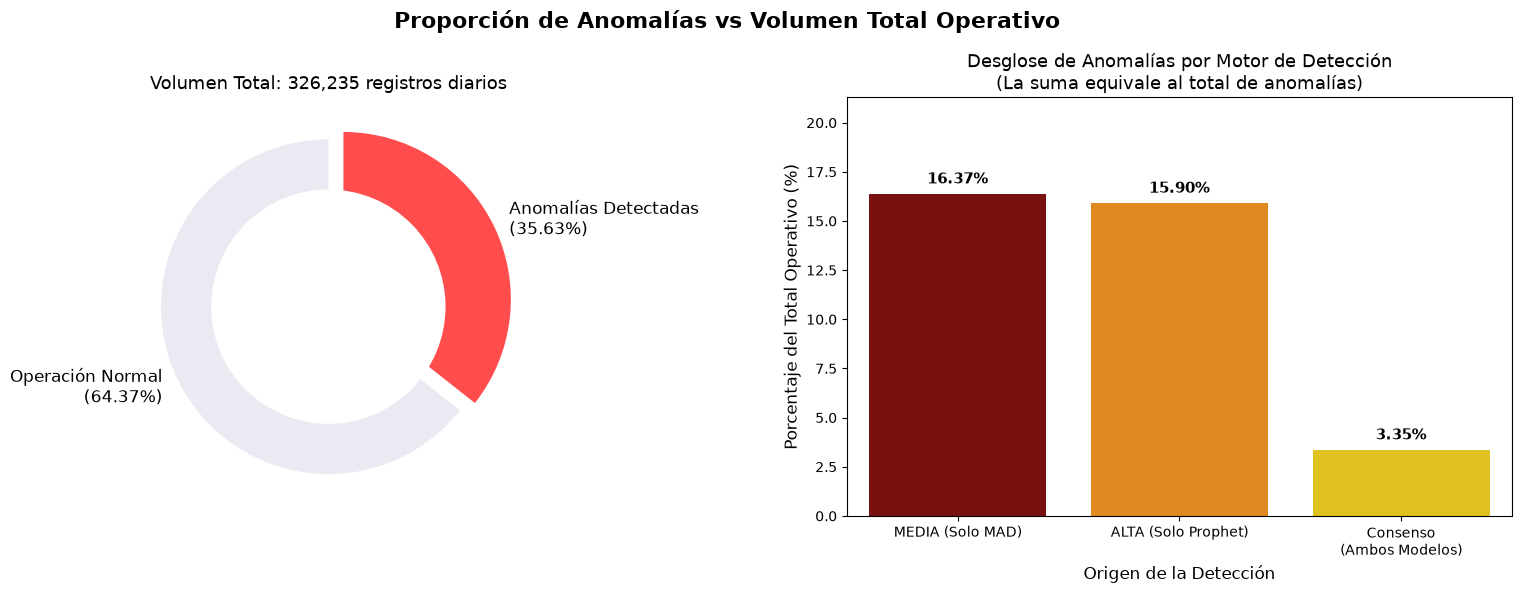

In [15]:
def graficar_balance_anomalias(df_total, df_anomalias):
    # ---------------------------------------------------------
    # Evitar el doble conteo
    # un mismo evento (fecha-línea-estacion) no sume dos veces
    # ---------------------------------------------------------
    df_anomalias_unicas = df_anomalias.drop_duplicates(subset=['fecha', 'linea', 'estacion']).copy()
    
    # 1. Cálculos de proporciones exactas
    total_registros = len(df_total)
    total_anomalos = len(df_anomalias_unicas)
    total_normales = total_registros - total_anomalos
    
    pct_normal = (total_normales / total_registros) * 100
    pct_anomalo = (total_anomalos / total_registros) * 100
    
    # Desglose de prioridades respecto al TOTAL de los datos
    conteo_prioridad = df_anomalias_unicas['prioridad_auditoria'].value_counts()
    
    # Renombrar índices para evidenciar que son mutuamente excluyentes

    mapeo_nombres = {
        'CRÍTICA (Consenso)': 'Consenso\n(Ambos Modelos)',
        'ALTA (Prophet)': 'Exclusivo\n(Solo Prophet)',
        'MEDIA (Z-Score)': 'Exclusivo\n(Solo MAD)'
    }
    conteo_prioridad.index = conteo_prioridad.index.map(lambda x: mapeo_nombres.get(x, x))
    
    pct_prioridades = (conteo_prioridad / total_registros) * 100
    
    # 2. Configuración del panel visual
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Proporción de Anomalías vs Volumen Total Operativo', fontsize=16, fontweight='bold')
    
    # --- El panorama general (Donut Chart) ---
    labels_macro = [f'Operación Normal\n({pct_normal:.2f}%)', f'Anomalías Detectadas\n({pct_anomalo:.2f}%)']
    sizes_macro = [total_normales, total_anomalos]
    colors_macro = ['#EAEAF2', '#FF4C4C']
    explode = (0, 0.1)  # Destacar las anomalías
    
    ax1.pie(sizes_macro, explode=explode, labels=labels_macro, colors=colors_macro, 
            autopct='', shadow=False, startangle=90, textprops={'fontsize': 12})
    
    # Convertir a gráfica de dona
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax1.add_patch(centre_circle)
    ax1.set_title(f'Volumen Total: {total_registros:,} registros diarios', fontsize=13)
    
    # --- Desglose de Criticidad (Bar Chart) ---
    sns.barplot(x=pct_prioridades.index, y=pct_prioridades.values, ax=ax2, 
                palette=['#8B0000', '#FF8C00', '#FFD700'])
    
    ax2.set_title('Desglose de Anomalías por Motor de Detección\n(La suma equivale al total de anomalías)', fontsize=13)
    ax2.set_ylabel('Porcentaje del Total Operativo (%)', fontsize=12)
    ax2.set_xlabel('Origen de la Detección', fontsize=12)
    
    # etiquetas de datos sobre las barras
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                     textcoords='offset points')
        
    # eje Y para porcentajes pequeños
    ax2.set_ylim(0, max(pct_prioridades.values) * 1.3)
    
    plt.tight_layout()
    plt.show()

# Ejecución de la gráfica 
graficar_balance_anomalias(df_limpio_copy, master_auditoria)

Código para obtención de la muestra calculada necesaria para un 95% de confianza y un 5% de margen de error:
$$n = \frac{N \cdot Z^2 \cdot p \cdot (1-p)}{(N-1) \cdot e^2 + Z^2 \cdot p \cdot (1-p)}$$
Donde:

$N$ = Tamaño de la población ($11,117$)

$Z$ = Nivel de confianza del 95% ($1.96$)

$e$ = Margen de error del 5% ($0.05$)$p$ = Probabilidad de ocurrencia ($0.5$, para maximizar el tamaño de muestra y ser conservadores)

Si sustituimos los valores:

$$n = \frac{11117 \cdot (1.96)^2 \cdot 0.5 \cdot 0.5}{(11116) \cdot (0.05)^2 + (1.96)^2 \cdot 0.5 \cdot 0.5} \approx 372$$

Técnica: Muestreo Estratificado Proporcional

Esta técnica divide los registros de anomalías críticas (donde prophet y MAD covergen) en "estratos" (subgrupos lógicos) y toma una muestra proporcional al peso de cada grupo. Si la Línea 1 tiene el 20% de las anomalías totales, la técnica se asegurará de que el 20% de tu muestra de 372 registros pertenezca exactamente a la Línea 1.

Los estratos más lógicos para nuestros datos son "Línea" y "Dirección" de la anomalía (Alza/Baja).

El siguiente código tiene como finalidad confirmar la replicabilidad de la extracción de la muestra, aunque la muestra utilizada para el resto del proyecto se extrajo del mismo algoritmo, fue una muestra unica extraida el 24 de abril del 2026

In [16]:
# 1. Filtrado de solo anomalías Críticas
df_criticas = master_auditoria[master_auditoria['prioridad_auditoria'] == 'CRÍTICA (Consenso)'].copy()
df_criticas.columns = df_criticas.columns.str.strip().str.lower()

#  la fila 1 siempre sera la misma en cualquier computadora
df_criticas = df_criticas.sort_values(by=['fecha', 'linea', 'estacion']).reset_index(drop=True)
# ---------------------------------------------------------

# 2. Definimos el tamaño de muestra que nos dio la fórmula estadística
tamaño_muestra = 372

# 3. Calculo de la fracción (el porcentaje de los 11,117 registros)
fraccion = tamaño_muestra / len(df_criticas)

# 4. Muestreo Estratificado Proporcional por Línea y Dirección de Anomalía
muestra_auditoria = df_criticas.groupby(
    ['linea', 'direccion_anomalia'], 
    group_keys=False
).sample(frac=fraccion, random_state=42)

# 5. CSV para la investigación manual
muestra_auditoria.to_csv('muestra_estratificada_auditoria_manual.csv', index=False)
muestra_auditoria.to_excel('muestra_estratificada_auditoria_manual.xlsx', index=False)

print(f"Población total de anomalías críticas: {len(df_criticas)}")
print(f"Tamaño de la muestra extraída: {len(muestra_auditoria)}")
print("Columnas preservadas exitosamente:", muestra_auditoria.columns.tolist())

Población total de anomalías críticas: 10940
Tamaño de la muestra extraída: 374
Columnas preservadas exitosamente: ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'fecha', 'afluencia', 'zscore_robusto', 'det_prophet', 'det_mad', 'prioridad_auditoria', 'linea', 'estacion', 'impacto_pasajeros', 'direccion_anomalia']


El siguiente código de comparativa muestra los gráficos de comparación del comportamiento del total de anomalías detectadas por nuestro modelo contra el comportamiento de la muestra replicable


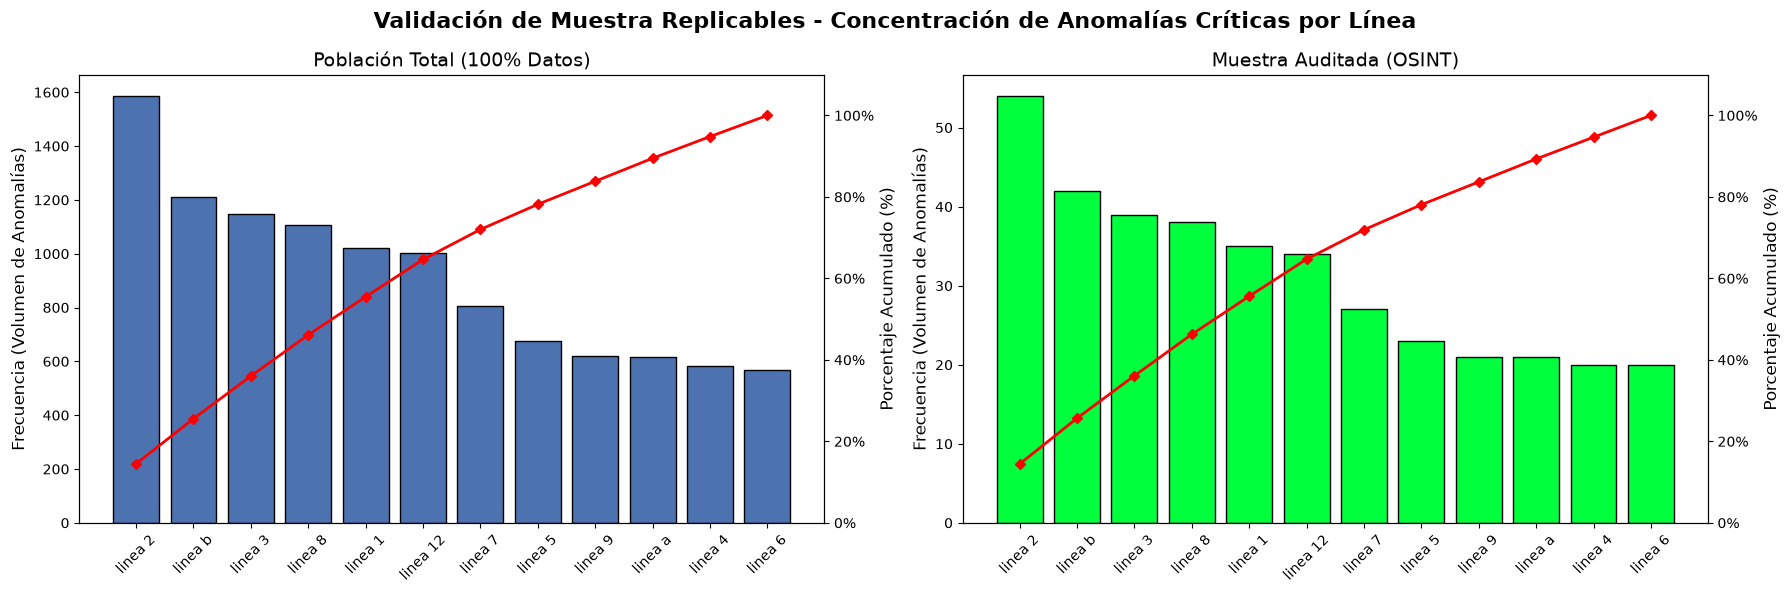

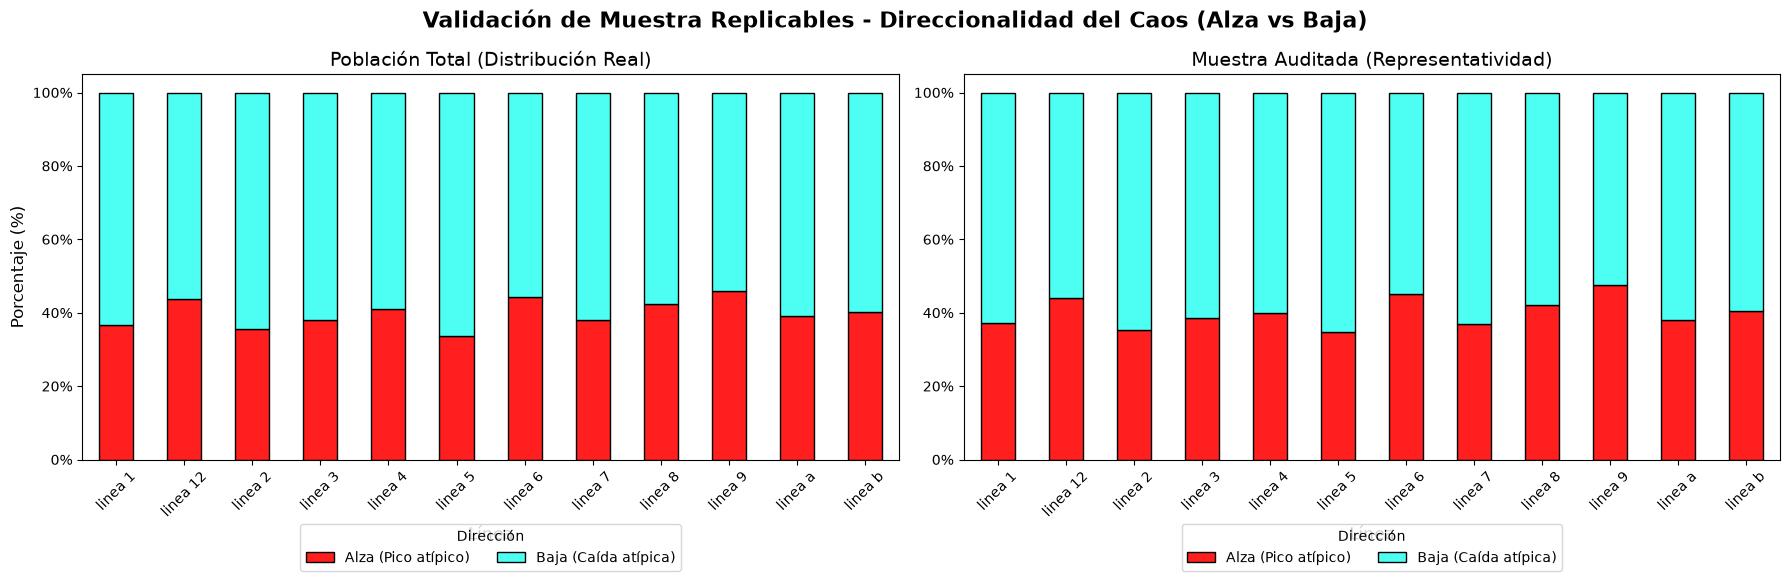

In [17]:
# 0. CARGA Y PREPARACIÓN DE DATOS
# Cargar el archivo de la población total de anomalías
df_poblacion = pd.read_csv('master_auditoria_consenso_MAD.csv') 
# Filtrar solo las anomalías críticas de la población total
df_pob_critica = df_poblacion[df_poblacion['prioridad_auditoria'].str.contains('CRÍTICA', na=False)].copy()

# Cargar el archivo de la muestra auditada manualmente
df_muestra = pd.read_csv('muestra_estratificada_auditoria_manual.csv')

# Normalizar los nombres de columnas para que coincidan (minúsculas)
df_muestra.columns = df_muestra.columns.str.strip().str.lower()
df_pob_critica.columns = df_pob_critica.columns.str.strip().str.lower()

# DIAGRAMA DE PARETO DUAL (Concentración por Línea)
def calcular_pareto(df, columna):
    """Calcula frecuencias y porcentaje acumulado para Pareto"""
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = [columna, 'frecuencia']
    conteo['pct'] = (conteo['frecuencia'] / conteo['frecuencia'].sum()) * 100
    conteo['acumulado'] = conteo['pct'].cumsum()
    return conteo

pareto_pob = calcular_pareto(df_pob_critica, 'linea')
pareto_muestra = calcular_pareto(df_muestra, 'linea')

# Crear figura para Pareto Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra Replicables - Concentración de Anomalías Críticas por Línea', fontsize=16, fontweight='bold')

# Función para graficar un Pareto
def plot_pareto(ax, data, title, color_bar):
    ax.bar(data['linea'], data['frecuencia'], color=color_bar, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Frecuencia (Volumen de Anomalías)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Eje secundario para el porcentaje acumulado
    ax_pct = ax.twinx()
    ax_pct.plot(data['linea'], data['acumulado'], color='red', marker='D', ms=5, linewidth=2)
    ax_pct.yaxis.set_major_formatter(PercentFormatter())
    ax_pct.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax_pct.set_ylim(0, 110)

plot_pareto(ax1, pareto_pob, f'Población Total (100% Datos)', '#4C72B0')
plot_pareto(ax2, pareto_muestra, f'Muestra Auditada (OSINT)', "#00FF3C")

plt.tight_layout()
plt.show()

# BALANCE DE DIRECCIONALIDAD (Alza vs Baja al 100%)
def preparar_direccionalidad(df):
    """Crea una tabla cruzada normalizada al 100% de línea vs dirección"""
    ct = pd.crosstab(df['linea'], df['direccion_anomalia'], normalize='index') * 100
    # Asegurar que las líneas estén en el mismo orden (alfabético/numérico)
    return ct.sort_index()

dir_pob = preparar_direccionalidad(df_pob_critica)
dir_muestra = preparar_direccionalidad(df_muestra)

# Crear figura para Direccionalidad Dual
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra Replicables - Direccionalidad del Caos (Alza vs Baja)', fontsize=16, fontweight='bold')

colores_dir = ["#FF1F1F", "#4DFFF3"] # Rojo suave para Baja, Verde agua para Alza

dir_pob.plot(kind='bar', stacked=True, ax=ax3, color=colores_dir, edgecolor='black')
ax3.set_title('Población Total (Distribución Real)', fontsize=14)
ax3.set_ylabel('Porcentaje (%)', fontsize=12)
ax3.set_xlabel('Línea', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

dir_muestra.plot(kind='bar', stacked=True, ax=ax4, color=colores_dir, edgecolor='black')
ax4.set_title('Muestra Auditada (Representatividad)', fontsize=14)
ax4.set_xlabel('Línea', fontsize=12)
ax4.yaxis.set_major_formatter(PercentFormatter())
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

A continuación se presentan las mismas gráficas de comparación de comportamiento pero para la muestra única obtenida el dia 24 de abril del 2026 que fue con la que se estuvo trabajando

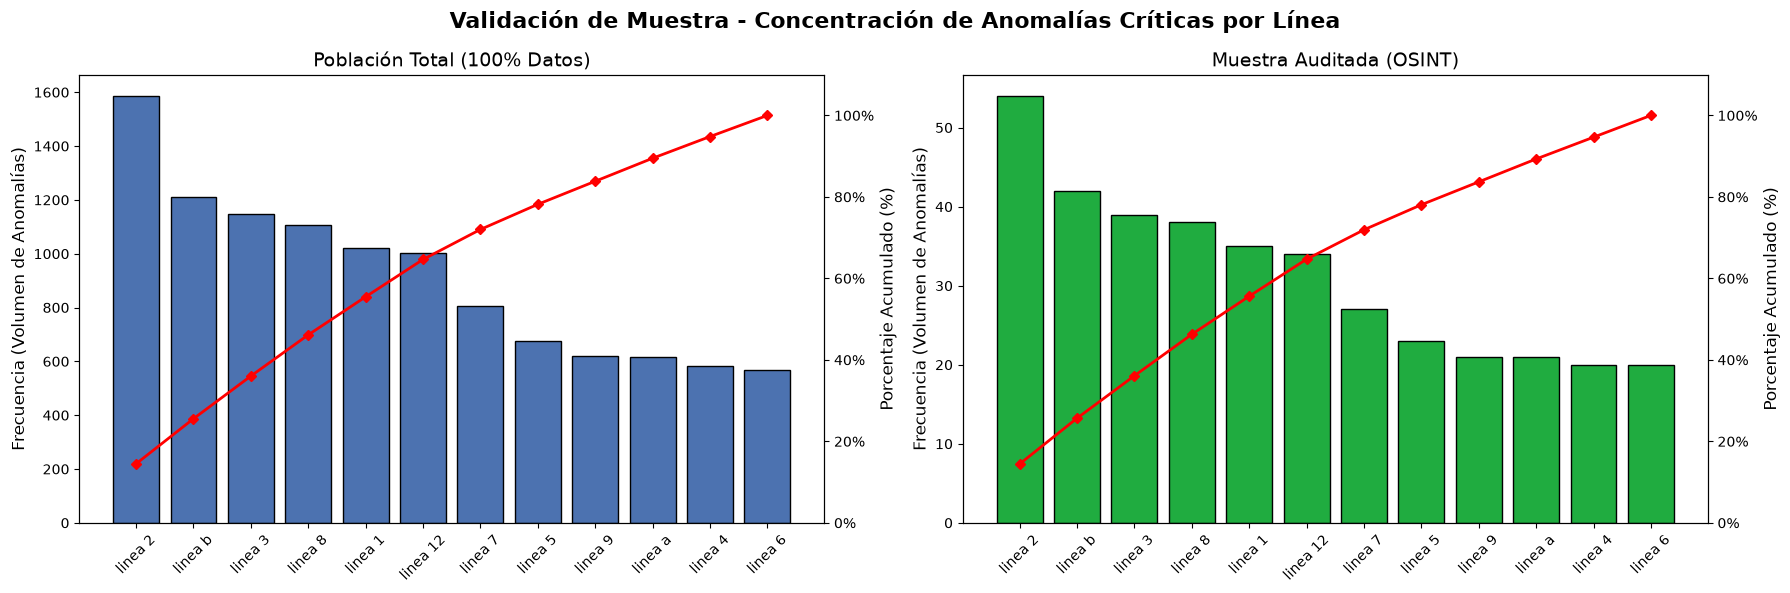

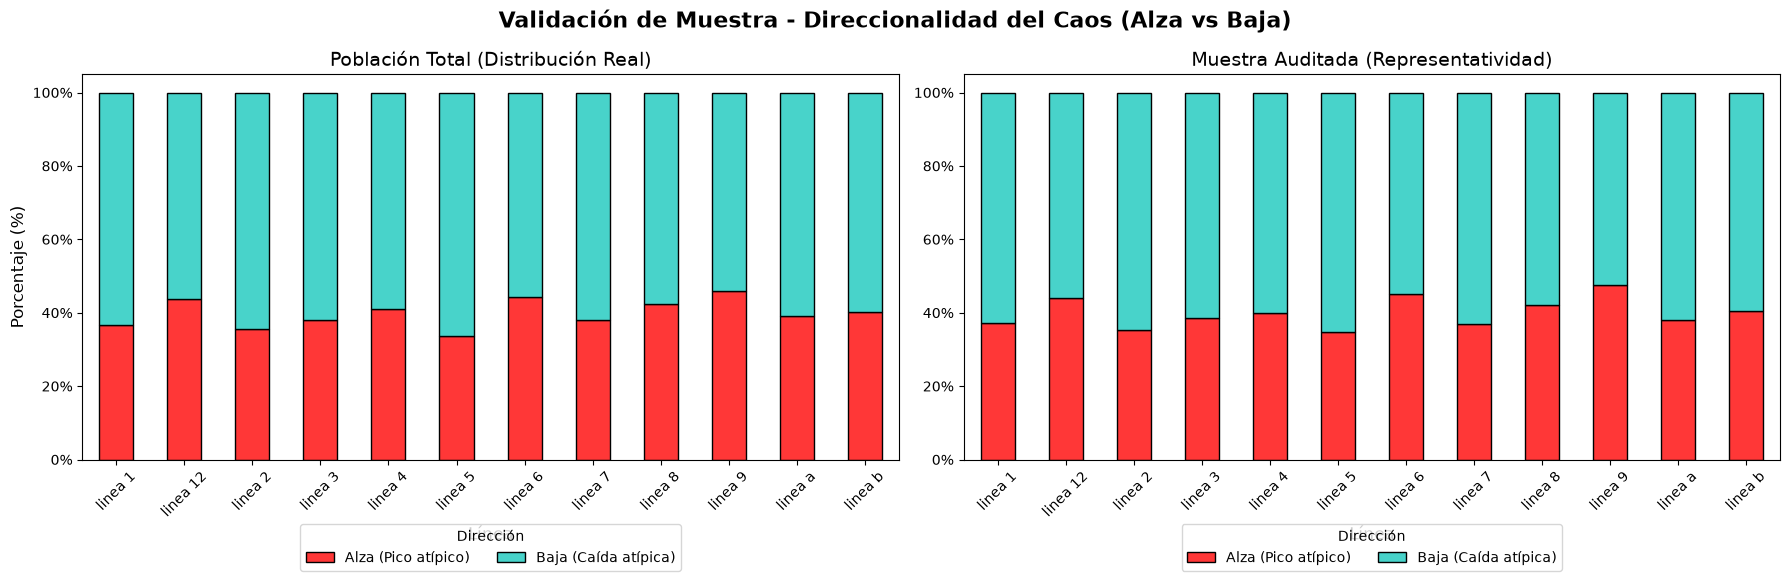

In [18]:
# 0. CARGA Y PREPARACIÓN DE DATOS
# Cargar el archivo maestro (Población Total)
df_poblacion = pd.read_csv('master_auditoria_consenso_MAD.csv') 
# Filtrar solo las anomalías críticas de la población total
df_pob_critica = df_poblacion[df_poblacion['prioridad_auditoria'].str.contains('CRÍTICA', na=False)].copy()

# Cargar el archivo de la muestra auditada manualmente
df_muestra = pd.read_excel('muestra_estratificada_auditoria_manual.xlsx')

# Normalizar los nombres de columnas para que coincidan (minúsculas)
df_muestra.columns = df_muestra.columns.str.lower()
df_pob_critica.columns = df_pob_critica.columns.str.lower()

# DIAGRAMA DE PARETO DUAL (Concentración por Línea)
def calcular_pareto(df, columna):
    """Calcula frecuencias y porcentaje acumulado para Pareto"""
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = [columna, 'frecuencia']
    conteo['pct'] = (conteo['frecuencia'] / conteo['frecuencia'].sum()) * 100
    conteo['acumulado'] = conteo['pct'].cumsum()
    return conteo

pareto_pob = calcular_pareto(df_pob_critica, 'linea')
pareto_muestra = calcular_pareto(df_muestra, 'linea')

# Crear figura para Pareto Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra - Concentración de Anomalías Críticas por Línea', fontsize=16, fontweight='bold')

# Función para graficar un Pareto
def plot_pareto(ax, data, title, color_bar):
    ax.bar(data['linea'], data['frecuencia'], color=color_bar, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Frecuencia (Volumen de Anomalías)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Eje secundario para el porcentaje acumulado
    ax_pct = ax.twinx()
    ax_pct.plot(data['linea'], data['acumulado'], color='red', marker='D', ms=5, linewidth=2)
    ax_pct.yaxis.set_major_formatter(PercentFormatter())
    ax_pct.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax_pct.set_ylim(0, 110)

plot_pareto(ax1, pareto_pob, f'Población Total (100% Datos)', '#4C72B0')
plot_pareto(ax2, pareto_muestra, f'Muestra Auditada (OSINT)', "#20AC40")

plt.tight_layout()
plt.show()

# BALANCE DE DIRECCIONALIDAD (Alza vs Baja al 100%)
def preparar_direccionalidad(df):
    """Crea una tabla cruzada normalizada al 100% de línea vs dirección"""
    ct = pd.crosstab(df['linea'], df['direccion_anomalia'], normalize='index') * 100
    # Asegurar que las líneas estén en el mismo orden (alfabético/numérico)
    return ct.sort_index()

dir_pob = preparar_direccionalidad(df_pob_critica)
dir_muestra = preparar_direccionalidad(df_muestra)

# Crear figura para Direccionalidad Dual
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra - Direccionalidad del Caos (Alza vs Baja)', fontsize=16, fontweight='bold')

colores_dir = ["#FF1D1DE2", "#48D3CA"] # Rojo suave para Baja, Verde agua para Alza

dir_pob.plot(kind='bar', stacked=True, ax=ax3, color=colores_dir, edgecolor='black')
ax3.set_title('Población Total (Distribución Real)', fontsize=14)
ax3.set_ylabel('Porcentaje (%)', fontsize=12)
ax3.set_xlabel('Línea', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

dir_muestra.plot(kind='bar', stacked=True, ax=ax4, color=colores_dir, edgecolor='black')
ax4.set_title('Muestra Auditada (Representatividad)', fontsize=14)
ax4.set_xlabel('Línea', fontsize=12)
ax4.yaxis.set_major_formatter(PercentFormatter())
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

C:\Users\Becario\AppData\Local\Temp\ipykernel_37768\2952930612.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Becario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:3399: UserWarning:

6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\Becario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:3399: UserWarning:

5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



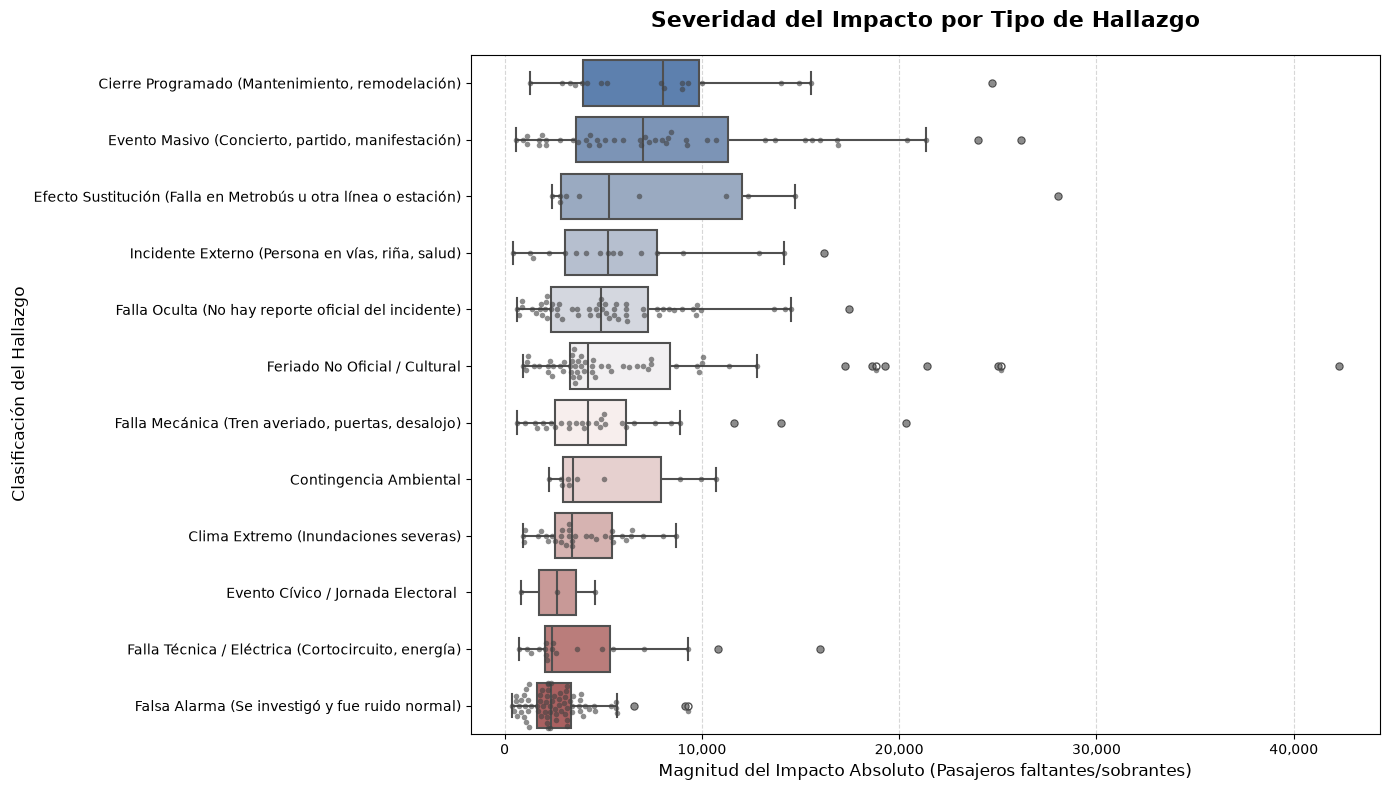

In [19]:
# 0. CARGA DE DATOS DE LA BITÁCORA MANUAL
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')

# Asegurar que los nombres de columnas coincidan
df_muestra.columns = df_muestra.columns.str.lower()
if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# Clasificación de causas encontradas en la investigación manual
conteo_causas = df_muestra['hallazgo'].value_counts().reset_index()
conteo_causas.columns = ['Causa', 'Frecuencia']
conteo_causas = conteo_causas.sort_values('Frecuencia', ascending=True)

total_anomalias = conteo_causas['Frecuencia'].sum()
conteo_causas['Porcentaje'] = (conteo_causas['Frecuencia'] / total_anomalias) * 100

#etiqueta de texto
conteo_causas['Texto_Etiqueta'] = conteo_causas.apply(
    lambda row: f"{int(row['Frecuencia'])} ({row['Porcentaje']:.1f}%)", axis=1
)

# calculo el valor máximo para extender el eje X
max_frecuencia = conteo_causas['Frecuencia'].max()

# Gráfico interactivo con paleta de colores cualitativa
fig_barras = px.bar(
    conteo_causas, 
    x='Frecuencia', 
    y='Causa', 
    orientation='h',
    text='Texto_Etiqueta',
    color='Causa', 
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='<b>Clasificación de Causas (Investigación OSINT)</b>',
    labels={'Frecuencia': 'Número de Incidentes Críticos', 'Causa': 'Clasificación del Hallazgo'}
)

fig_barras.update_traces(
    textposition='outside', 
    textfont=dict(size=10, color='#333333'),
    cliponaxis=False  #  Evita que el eje corte el texto
)

fig_barras.update_layout(
    template='plotly_white', 
    height=500,
    showlegend=False, 
    xaxis=dict(
        showgrid=True, 
        gridcolor='#E5E5E5',
        range=[0, max_frecuencia * 1.2] # Expande el eje X un 20% más allá de la barra más grande
    ),
    yaxis=dict(showgrid=False),
    margin=dict(r=150) # Aumenta el margen derecho de la imagen (de 90 a 150)
)

fig_barras.show()


# ANÁLISIS DE SEVERIDAD 
plt.figure(figsize=(14, 8))
plt.title('Severidad del Impacto por Tipo de Hallazgo', fontsize=16, fontweight='bold', pad=20)

# Convertir impacto a absoluto
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# Ordenar las cajas
orden_cajas = df_muestra.groupby('hallazgo')['impacto_absoluto'].median().sort_values(ascending=False).index


sns.boxplot(
    data=df_muestra, 
    y='hallazgo', 
    x='impacto_absoluto', 
    order=orden_cajas,
    palette='vlag',
    linewidth=1.5,
    fliersize=5
)

# Los puntos de distribución real
sns.swarmplot(
    data=df_muestra, 
    y='hallazgo', 
    x='impacto_absoluto', 
    order=orden_cajas,
    color='.25',
    alpha=0.6,
    size=4
)

plt.xlabel('Magnitud del Impacto Absoluto (Pasajeros faltantes/sobrantes)', fontsize=12)
plt.ylabel('Clasificación del Hallazgo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Formatear eje X
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

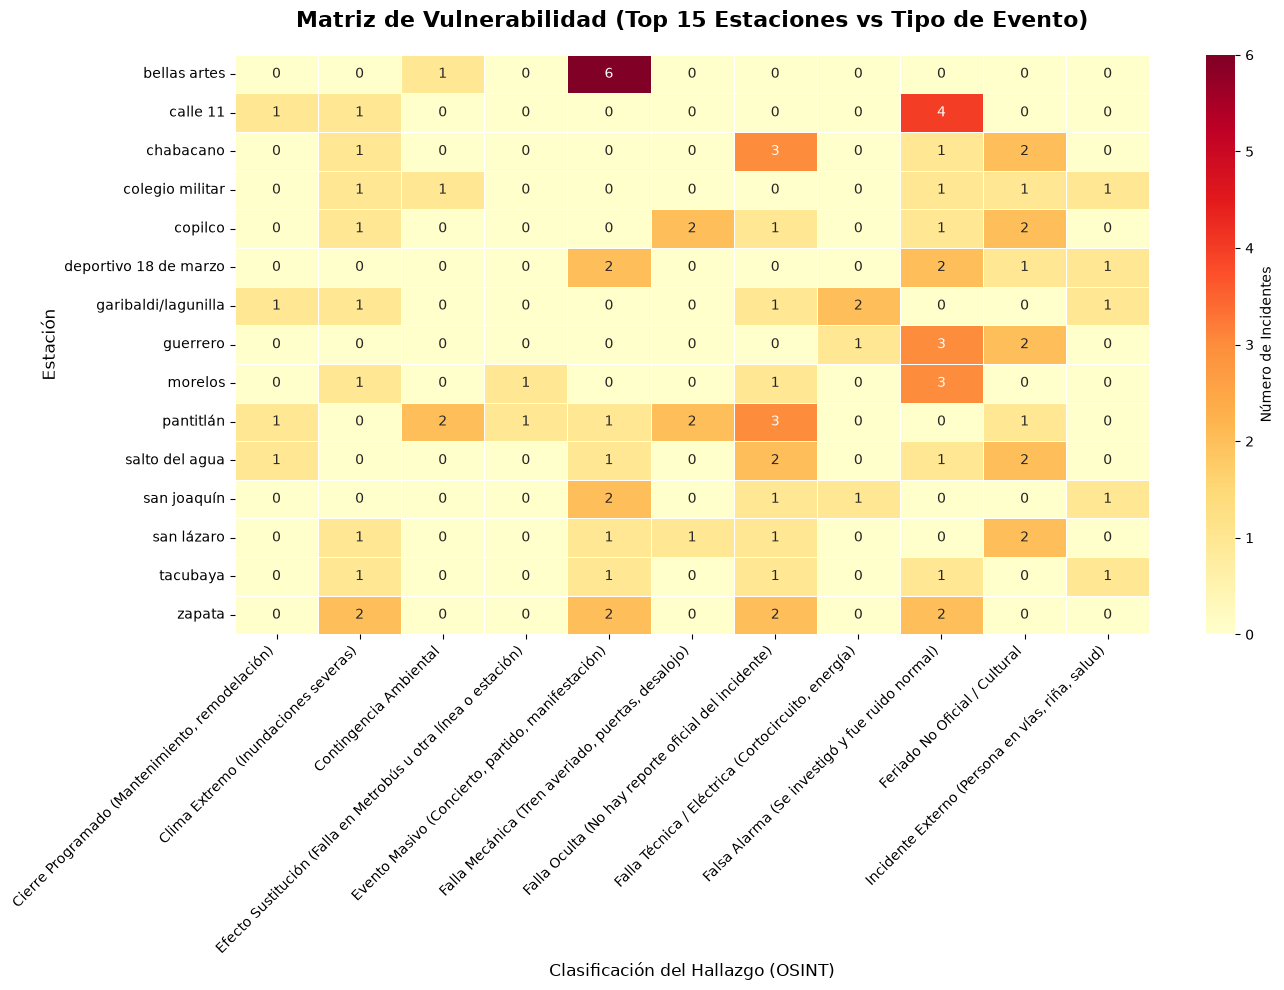


 TOP 5 CASOS CRÍTICOS

Caso de Estudio #1 | Impacto: 42,277 pasajeros (Alza (Pico atípico))
Fecha: 2022-01-02 0:00:00 | Línea: linea 8 | Estación: constitución de 1917
Causa Detectada: Feriado No Oficial / Cultural
Descripción: Afluencia a la alza dado eventos de temporada de inicio de año e inicio de recuperación de periodo postpandemia
Evidencia: Sin fuente URL

Caso de Estudio #2 | Impacto: -28,037 pasajeros (Baja (Caída atípica))
Fecha: 2024-03-29 0:00:00 | Línea: linea b | Estación: buenavista
Causa Detectada: Efecto Sustitución (Falla en Metrobús u otra línea o estación)
Descripción: Buenavista, los usuarios reportan tiempos de espera de 10 minutos en la estación San Lázaro (que conecta con el Metrobús).
Evidencia: https://www.milenio.com/politica/comunidad/metro-metrobus-cdmx-hoy-29-marzo-2024-ultimas-noticias-en-vivo-atm

Caso de Estudio #3 | Impacto: -26,188 pasajeros (Baja (Caída atípica))
Fecha: 2025-11-25 0:00:00 | Línea: linea 2 | Estación: pino suárez
Causa Detectada: Ev

In [20]:
# 0. CARGA DE DATOS
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')

# los nombres de columnas estan estandarizados (minúsculas para el código)
df_muestra.columns = df_muestra.columns.str.lower()
# La columna se llama 'hallazgo_principal', se renombra a 'hallazgo' por simplicidad
if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# MATRIZ DE VULNERABILIDAD (Heatmap)
# se toman solo el TOP 15 de estaciones más afectadas
top_estaciones = df_muestra['estacion'].value_counts().head(15).index

# Filtrado del dataframe solo con esas estaciones
df_top_est = df_muestra[df_muestra['estacion'].isin(top_estaciones)]

# Creamos una tabla cruzada entre Estación y Hallazgo
matriz_vuln = pd.crosstab(df_top_est['estacion'], df_top_est['hallazgo'])

plt.figure(figsize=(14, 10))
plt.title('Matriz de Vulnerabilidad (Top 15 Estaciones vs Tipo de Evento)', fontsize=16, fontweight='bold', pad=20)

# Generamos el Mapa de Calor
sns.heatmap(
    matriz_vuln, 
    annot=True,          # Muestra el número dentro del cuadro
    fmt='d',             # Formato entero
    cmap='YlOrRd',       # Paleta de colores: Amarillo -> Naranja -> Rojo (Alerta)
    linewidths=.5,       # Líneas de separación
    cbar_kws={'label': 'Número de Incidentes'}
)

plt.xlabel('Clasificación del Hallazgo (OSINT)', fontsize=12)
plt.ylabel('Estación', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# EXTRACCIÓN DE CASOS CRÍTICOS
print("\n" + "="*60)
print(" TOP 5 CASOS CRÍTICOS")
print("="*60)

# Calculo del impacto absoluto para encontrar los eventos más violentos
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# Orden de mayor a menor impacto y obtención de los 5 principales
top_casos = df_muestra.sort_values('impacto_absoluto', ascending=False).head(5)

# Iteración sobre los 5 casos para imprimirlos con formato de "Ficha Técnica"
for i, (_, row) in enumerate(top_casos.iterrows(), 1):
    print(f"\nCaso de Estudio #{i} | Impacto: {row['impacto']:,.0f} pasajeros ({row['direccion_anomalia']})")
    print(f"Fecha: {row['fecha']} | Línea: {row['linea']} | Estación: {row['estacion']}")
    print(f"Causa Detectada: {row['hallazgo']}")
    
    # Manejar el caso de que la descripción esté vacía
    desc = row.get('descripcion_incidente', 'Sin descripción detallada')
    if pd.isna(desc): desc = 'Sin descripción detallada'
    
    print(f"Descripción: {desc}")
    
    fuente = row.get('link_fuente_1', 'Sin fuente URL')
    if pd.isna(fuente): fuente = 'Sin fuente URL'
    print(f"Evidencia: {fuente}")

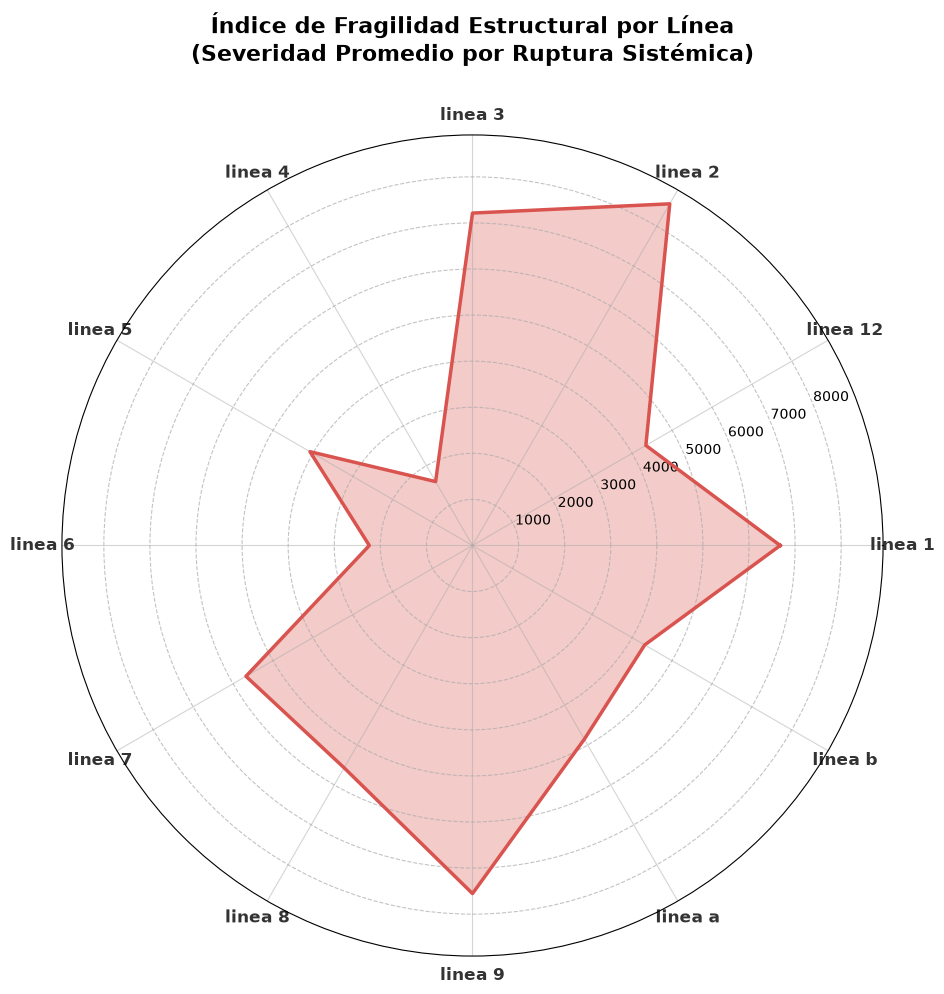

In [21]:
# 0. CARGA Y PREPARACIÓN DE DATOS
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')
df_muestra.columns = df_muestra.columns.str.lower()

if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# Uso del impacto absoluto para medir el "shock" sin importar si es alza o baja
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# CÁLCULO DEL ÍNDICE DE FRAGILIDAD / RESILIENCIA
# Agrupación por línea y cálculo del Promedio de Impacto por evento
resiliencia = df_muestra.groupby('linea')['impacto_absoluto'].mean().reset_index()

# Ordenar las líneas alfabéticamente para que el radar tenga un orden lógico
resiliencia = resiliencia.sort_values('linea')

# Preparar listas de datos para el Radar Chart
categorias = resiliencia['linea'].tolist()
valores = resiliencia['impacto_absoluto'].tolist()

# El gráfico de radar necesita que el último valor 
# sea igual al primero para que el polígono "cierre" visualmente.
valores += valores[:1]

# Calcular los ángulos de la circunferencia para cada categoría (Línea)
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

# DIBUJAR EL GRÁFICO DE RADAR
# Iniciar figura especificando que es una proyección polar
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Dibujar el contorno del polígono
ax.plot(angulos, valores, color='#D9534F', linewidth=2.5, linestyle='solid', label='Impacto Promedio (Fragilidad)')

# Rellenar el área interior
ax.fill(angulos, valores, color='#D9534F', alpha=0.3)

# Configurar las etiquetas de las Líneas en el borde del círculo
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=12, fontweight='bold', color='#333333')

ax.yaxis.grid(True, color='#AAAAAA', linestyle='--', alpha=0.7)
ax.xaxis.grid(True, color='#AAAAAA', linestyle='-', alpha=0.5)

# Título del gráfico
plt.title('Índice de Fragilidad Estructural por Línea\n(Severidad Promedio por Ruptura Sistémica)', 
          size=16, fontweight='bold', y=1.08)

plt.tight_layout()
plt.show()

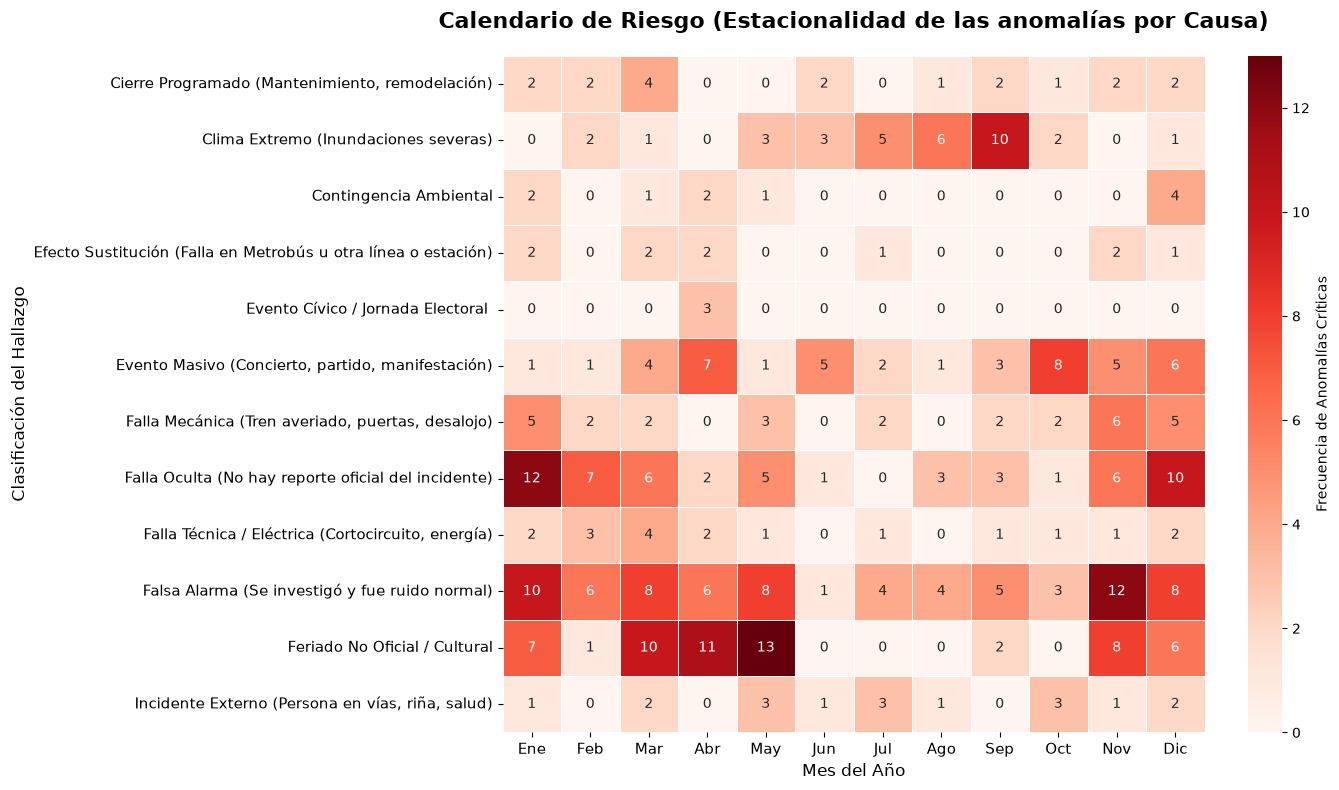

In [22]:
# 1. Cargar la bitácora oficial de investigación manual
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv') # O bitacora_oficial_reparada.csv
df_muestra.columns = df_muestra.columns.str.lower()

if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})

# 2. Extraer el mes de la fecha
# Converción de la columna a tipo datetime
df_muestra['fecha'] = pd.to_datetime(df_muestra['fecha'])

# número del mes (1 al 12)
df_muestra['mes_num'] = df_muestra['fecha'].dt.month

# converción de los números a nombres de meses en español para la gráfica
meses_esp = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 
             7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_muestra['mes'] = df_muestra['mes_num'].map(meses_esp)

# 3. Crear la Matriz Temporal
heatmap_data = pd.crosstab(df_muestra['hallazgo'], df_muestra['mes'])

# Reorden de las columnas para que no salgan alfabéticamente, sino en orden de calendario
meses_presentes = [m for m in meses_esp.values() if m in heatmap_data.columns]
heatmap_data = heatmap_data[meses_presentes]

# 4. Graficar el Heatmap
plt.figure(figsize=(14, 8))
plt.title('Calendario de Riesgo (Estacionalidad de las anomalías por Causa)', fontsize=16, fontweight='bold', pad=20)

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='d', 
    cmap='Reds', # Paleta de alerta
    linewidths=.5,
    cbar_kws={'label': 'Frecuencia de Anomalías Críticas'}
)

plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Clasificación del Hallazgo', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
# 1. Preparación de los datos
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')
df_muestra.columns = df_muestra.columns.str.lower()

if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

df_muestra['impacto_abs'] = df_muestra['impacto'].abs()
impacto_causas = df_muestra.groupby('hallazgo')['impacto_abs'].sum().reset_index()

# Filtro flexible con .str.contains()
total_detectado = impacto_causas['impacto_abs'].sum()

# Busca cualquier fila que contenga las palabras "Falla Oculta"
mascara_oculta = impacto_causas['hallazgo'].str.contains('Falla Oculta', case=False, na=False)

# Separación correcta entre causas explicadas y la falla oculta, asegurando que la suma de la falla oculta se mantenga como un bloque independiente
explicadas = impacto_causas[~mascara_oculta].sort_values('impacto_abs', ascending=False)
falla_oculta_valor = impacto_causas[mascara_oculta]['impacto_abs'].sum()

# Construcción de la estructura de la Cascada
etiquetas = ["Impacto Total Detectado"] + explicadas['hallazgo'].tolist() + ["Falla sin reportar"]

valores = [total_detectado] + [-v for v in explicadas['impacto_abs']] + [0]
medidas = ["relative"] + ["relative"] * len(explicadas) + ["total"]

# Creación de la Gráfica Sustractiva
# Dividición entre 1,000 y uso del sufijo 'K' para Miles, con 0 decimales para mayor limpieza
text_miles = [f"{v/1000:.0f}K" if v >= 0 else f"-{abs(v)/1000:.0f}K" for v in valores[:-1]] + [f"{falla_oculta_valor/1000:.0f}K"]

fig_waterfall = go.Figure(go.Waterfall(
    name="Auditoría",
    orientation="v",
    measure=medidas,
    x=etiquetas,
    y=valores,
    textposition="outside",
    text=text_miles, # nuevo formato en miles
    connector={"line": {"color": "rgb(63, 63, 63)", "width": 1.5}},
    increasing={"marker": {"color": "#4C72B0"}}, # Azul para el Total Inicial
    decreasing={"marker": {"color": "#AAB6C4"}}, # Gris para lo Explicado
    totals={"marker": {"color": "#D9534F"}}     # Rojo para la Deuda de fallas ocultas
))

fig_waterfall.update_layout(
    title='<b> Auditoría de fallas sin reportar</b><br><sup>Descontando causas explicadas (OSINT) del total de la muestra de anomalías críticas</sup>',
    waterfallgap=0.3,
    template='plotly_white',
    height=700,
    margin=dict(t=100, b=200),
    yaxis=dict(title='Impacto en Pasajeros (Absoluto)', tickformat=","),
    xaxis=dict(tickangle=-45)
)

fig_waterfall.show()

# **CONTINUACIÓN DE PROPHET: RIESGO DE ANOMALÍA A FUTURO (Random Forest / XGBoost)**

Prophet sigue siendo el modelo base: pronostica cuántos pasajeros se esperan en cada estación cada día (`yhat` con su intervalo). Random Forest / XGBoost **se apoyan en ese pronóstico** para dar el siguiente paso: estimar, para cada estación-día futuro, la **probabilidad de que la afluencia real se salga de lo que Prophet espera** y termine como anomalía **CRÍTICA (Consenso)**.

Cómo está planteado (y por qué):

- **Los positivos vienen del motor de auditoría** (`series_prophet`, guardado en `data/processed/prophet_series.pkl`): cada estación-día trae el pronóstico de Prophet, sus componentes y su etiqueta. `es_critica = 1` si el día fue CRÍTICA; el resto son negativos (el CSV de anomalías por sí solo no sirve para entrenar porque solo contiene positivos). Se elige CRÍTICA (~3% de los días) porque las otras categorías marcan más de un tercio de los días y no discriminan.
- **Variables que caracterizan cada día y estación** (todas conocibles para fechas futuras, por eso no se usan rezagos de afluencia):
  - *Extraídas de Prophet:* nivel esperado del día (`yhat_rel`), ancho de su intervalo (`banda_rel`), **efecto de festivos** que Prophet estimó para ese día (`efecto_festivo_rel`, componente `holidays` del modelo con festivos de México) y **estacionalidad anual** aprendida (`estacional_anual_rel`, componente `yearly`).
  - *Calendario y estacionalidad del año:* mes, semana, día del mes, festivos oficiales, cercanía a festivos y a Semana Santa, y **feriados no oficiales/culturales** hallados en la investigación OSINT (14-feb, 10-may, 1/2-nov, 12-dic, etc.; lista editable en `FECHAS_CULTURALES`).
  - *Clima (aproximación climatológica):* no hay clima diario ni se puede conocer a futuro, así que se usan temporadas: lluvias (jun-oct), calor (mar-may) y contingencia ambiental (feb-jun), acordes con los meses en que la bitácora OSINT encontró clima extremo y contingencias. El modelo aprende cuánto riesgo extra trae cada temporada, no el clima real de un día específico.
  - *Carácter de la estación (demanda):* demanda media (`log_demanda`), percentil de demanda entre estaciones, variabilidad (`cv_demanda`), tasa histórica de críticas y tasa histórica de críticas *al alza* (picos por sobrecarga). Permiten ver si las estaciones de alta demanda tienden a presentar más anomalías. Se calculan solo con el tramo de entrenamiento.
- **Sin sesgo de fin de semana.** Las críticas se concentran en fines de semana (domingo ≈ 7% de los estación-días vs ≈ 2% entre semana; 31% de todas las críticas caen en domingo), en parte por cómo funciona el detector: la bitácora OSINT muestra que 45% de las *falsas alarmas* son domingo. Si el modelo aprendiera eso, solo diría "el domingo es riesgoso" en vez de detectar lo que la investigación OSINT sí encontró (clima extremo, eventos masivos/manifestaciones, jornadas electorales, feriados no oficiales, estacionalidad del año). Por eso:
  1. **No** se usan `dia_semana` ni `es_fin_semana` como variables (solo en el modelo de contraste).
  2. Las variables de Prophet se **normalizan contra el mismo día de la semana de cada estación** y el componente semanal de Prophet no se usa, de modo que solo capturan desvíos por estacionalidad, festivos o tendencia, no el ciclo semanal.
  3. El entrenamiento **balancea por día de la semana**: cada positivo pesa (tasa global / tasa de su día), así la prevalencia ponderada es igual todos los días y el modelo debe encontrar la señal *dentro* de cada día.
  4. Se **evalúa dentro de cada día de la semana** (AP y ROC-AUC intra-día) y se compara contra un modelo de contraste que sí ve el día de la semana.
  5. La propuesta final se ordena por `riesgo_vs_mismo_dia`, que compara cada estación-día contra uno típico *del mismo día de la semana*.
- **Validación temporal** (entrena con el 80% más antiguo de las fechas, evalúa en el 20% más reciente). Se compara contra referencias (solo día de la semana, solo estación) y contra el modelo sin las variables de Prophet.
- **Alcance:** la etiqueta es lo que *detectan Prophet + MAD*, no incidentes confirmados (solo la muestra OSINT tiene causa verificada), y en el periodo histórico `yhat` y sus componentes son el ajuste dentro de muestra. Clima diario, manifestaciones y jornadas electorales concretas no se pueden anticipar con este calendario. Sirve para **priorizar** días/estaciones de vigilancia, no como predictor exacto de fallas.

In [24]:
import holidays
from dateutil.easter import easter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("xgboost no esta instalado: solo se entrenara Random Forest (pip install xgboost)")

# 1. Pronostico de Prophet por estacion-dia (historico + dias futuros) que dejo el motor de auditoria
if 'series_prophet' not in globals():
    series_prophet = pd.read_pickle('data/processed/prophet_series.pkl')
series_ml = series_prophet.rename(columns={'ds': 'fecha'})
series_ml['fecha'] = pd.to_datetime(series_ml['fecha'])
series_ml['dia_semana'] = series_ml['fecha'].dt.dayofweek

# Historico con etiqueta (1 = anomalia CRITICA) y dias futuros solo con pronostico
datos_ml = series_ml[~series_ml['es_futuro']].copy()
datos_ml['es_critica'] = datos_ml['prioridad_auditoria'].str.contains('CRÍTICA', na=False).astype(int)
futuro_ml = series_ml[series_ml['es_futuro']].copy()

print(f"Estacion-dias historicos: {len(datos_ml):,} | criticas: {datos_ml['es_critica'].sum():,} "
      f"({datos_ml['es_critica'].mean()*100:.2f}%)")
print(f"Rango historico: {datos_ml['fecha'].min().date()} -> {datos_ml['fecha'].max().date()}")

nombres_dia = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
sesgo_dia = datos_ml.groupby('dia_semana')['es_critica'].mean().mul(100).round(2)
sesgo_dia.index = nombres_dia
print("\n% de estacion-dias CRITICOS por dia de la semana (sesgo del detector que NO debe aprender el modelo):")
print(sesgo_dia.to_string())

# 2. Variables de estacionalidad / calendario (conocidas para cualquier fecha futura)
anios_cal = range(datos_ml['fecha'].dt.year.min(), datos_ml['fecha'].dt.year.max() + 3)
festivos_mx = pd.DatetimeIndex(sorted(holidays.country_holidays('MX', years=anios_cal).keys()))
pascuas = pd.DatetimeIndex([pd.Timestamp(easter(a)) for a in anios_cal])
codigo_linea = {l: i for i, l in enumerate(sorted(datos_ml['linea'].unique()))}

# Feriados no oficiales / culturales (mes, dia) que la investigacion OSINT encontro asociados a anomalias
FECHAS_CULTURALES = {(1, 2), (1, 6), (2, 14), (3, 8), (5, 10), (9, 15), (11, 1), (11, 2), (12, 12), (12, 24), (12, 31)}

def features_calendario(fechas):
    f = pd.DatetimeIndex(fechas)
    pos = festivos_mx.searchsorted(f)
    siguiente = festivos_mx[np.minimum(pos, len(festivos_mx) - 1)]
    anterior = festivos_mx[np.maximum(pos - 1, 0)]
    cercana = pascuas[pascuas.get_indexer(f, method='nearest')]
    return pd.DataFrame({
        'fecha': f,
        'mes': f.month,
        'dia_mes': f.day,
        'semana_anio': f.isocalendar().week.values.astype(int),
        'es_festivo': f.isin(festivos_mx).astype(int),
        'es_feriado_no_oficial': [int((m, d) in FECHAS_CULTURALES) for m, d in zip(f.month, f.day)],
        'dias_a_festivo': np.clip((siguiente - f).days, 0, 30),
        'dias_desde_festivo': np.clip((f - anterior).days, 0, 30),
        'dias_a_semana_santa': np.clip((f - cercana).days, -30, 30),  # negativo = antes de Pascua
        # Clima como climatologia (no hay clima diario ni se conoce a futuro): temporadas de CDMX
        'temporada_lluvias': f.month.isin([6, 7, 8, 9, 10]).astype(int),
        'temporada_calor': f.month.isin([3, 4, 5]).astype(int),
        'temporada_contingencia': f.month.isin([2, 3, 4, 5, 6]).astype(int),
        # Solo para normalizar/balancear y para el contraste "sesgado" (no entran en FEATURES_ML)
        'dia_semana': f.dayofweek,
        'es_fin_semana': (f.dayofweek >= 5).astype(int)
    })

# 3. Variables que salen de Prophet, normalizadas contra el MISMO dia de la semana de la estacion
#    (asi no cargan el ciclo semanal). El componente semanal de Prophet no se usa.
datos_ml['banda_rel'] = (datos_ml['yhat_upper'] - datos_ml['yhat_lower']) / datos_ml['yhat'].clip(lower=1)
nivel_estacion_dia = (datos_ml.groupby(['linea', 'estacion', 'dia_semana'])
                      .agg(nivel_dia=('yhat', 'mean'), banda_dia=('banda_rel', 'mean')).reset_index())
nivel_estacion_dia['nivel_dia'] = nivel_estacion_dia['nivel_dia'].clip(lower=1)
nivel_estacion_dia['banda_dia'] = nivel_estacion_dia['banda_dia'].clip(lower=1e-3)
nivel_estacion = (datos_ml.groupby(['linea', 'estacion'])['yhat'].mean().clip(lower=1)
                  .rename('nivel_estacion').reset_index())

# 4. Caracter de cada estacion (solo con el tramo de entrenamiento que se le pase)
def stats_estacion(df):
    g = df.assign(clave=df['linea'] + '|' + df['estacion'],
                  crit_alza=((df['es_critica'] == 1) & (df['afluencia'] > df['yhat'])).astype(int)).groupby('clave')
    st = pd.DataFrame({
        'tasa_hist_estacion': g['es_critica'].mean(),        # que tan seguido la estacion sale critica
        'tasa_hist_alza': g['crit_alza'].mean(),             # ...y por picos al alza (sobrecarga)
        'demanda_media': g['afluencia'].mean(),
        'cv_demanda': g['afluencia'].std() / g['afluencia'].mean()   # variabilidad de la demanda
    })
    st['log_demanda'] = np.log10(st['demanda_media'].clip(lower=1))
    st['percentil_demanda'] = st['demanda_media'].rank(pct=True)     # 1.0 = de las mas demandadas
    return st.drop(columns='demanda_media')

FEATURES_CAL = ['mes', 'dia_mes', 'semana_anio', 'es_festivo', 'es_feriado_no_oficial',
                'dias_a_festivo', 'dias_desde_festivo', 'dias_a_semana_santa',
                'temporada_lluvias', 'temporada_calor', 'temporada_contingencia']
FEATURES_PROPHET = ['yhat_rel', 'banda_rel', 'efecto_festivo_rel', 'estacional_anual_rel']
FEATURES_ESTACION = ['linea_cod', 'tasa_hist_estacion', 'tasa_hist_alza', 'log_demanda', 'percentil_demanda', 'cv_demanda']
FEATURES_SIN_PROPHET = FEATURES_CAL + FEATURES_ESTACION
FEATURES_ML = FEATURES_CAL + FEATURES_PROPHET + FEATURES_ESTACION
FEATURES_SESGADO = FEATURES_ML + ['dia_semana', 'es_fin_semana']   # contraste: modelo que SI ve el dia de la semana

def armar_matriz(df, stats):
    df = df.drop(columns=['dia_semana'], errors='ignore')
    X = (df.merge(features_calendario(df['fecha'].unique()), on='fecha', how='left')
           .merge(nivel_estacion_dia, on=['linea', 'estacion', 'dia_semana'], how='left')
           .merge(nivel_estacion, on=['linea', 'estacion'], how='left'))
    yhat_pos = X['yhat'].clip(lower=1)
    X['yhat_rel'] = yhat_pos / X['nivel_dia']
    X['banda_rel'] = ((X['yhat_upper'] - X['yhat_lower']) / yhat_pos) / X['banda_dia']
    X['efecto_festivo_rel'] = X['holidays'].fillna(0) / X['nivel_estacion']     # efecto de festivos segun Prophet
    X['estacional_anual_rel'] = X['yearly'].fillna(0) / X['nivel_estacion']     # estacionalidad anual segun Prophet
    X = X.merge(stats, left_on=X['linea'] + '|' + X['estacion'], right_index=True, how='left')
    X[stats.columns] = X[stats.columns].fillna(stats.median())                  # estaciones sin historia en el tramo
    X['linea_cod'] = X['linea'].map(codigo_linea)
    return X

Estacion-dias historicos: 326,235 | criticas: 10,940 (3.35%)
Rango historico: 2022-01-01 -> 2026-07-31

% de estacion-dias CRITICOS por dia de la semana (sesgo del detector que NO debe aprender el modelo):
Lunes        2.69
Martes       1.97
Miercoles    1.88
Jueves       2.46
Viernes      2.92
Sabado       4.30
Domingo      7.26


In [25]:
# 5. Division temporal: 80% de fechas mas antiguas para entrenar, 20% mas reciente para evaluar
fechas_ordenadas = np.sort(datos_ml['fecha'].unique())
fecha_corte = pd.Timestamp(fechas_ordenadas[int(len(fechas_ordenadas) * 0.8)])

df_tr = datos_ml[datos_ml['fecha'] < fecha_corte]
df_te = datos_ml[datos_ml['fecha'] >= fecha_corte]

# Las estadisticas por estacion (tasas, demanda) se calculan SOLO con el tramo de entrenamiento
stats_tr = stats_estacion(df_tr)
X_tr = armar_matriz(df_tr, stats_tr)
X_te = armar_matriz(df_te, stats_tr)
y_tr, y_te = X_tr['es_critica'], X_te['es_critica']

print(f"Corte: {fecha_corte.date()} | train: {len(X_tr):,} ({y_tr.mean()*100:.2f}% criticas) "
      f"| test: {len(X_te):,} ({y_te.mean()*100:.2f}% criticas)")

# Balanceo por dia de la semana: cada positivo pesa (tasa global / tasa de su dia), de modo que
# la prevalencia ponderada es la misma todos los dias y el modelo tiene que buscar la senal DENTRO del dia
tasa_dia_tr = y_tr.groupby(X_tr['dia_semana']).mean()
def pesos_balance_dia(X, y, tasa_dia, tasa_global):
    return np.where(y == 1, tasa_global / X['dia_semana'].map(tasa_dia), 1.0)
w_tr = pesos_balance_dia(X_tr, y_tr, tasa_dia_tr, y_tr.mean())

def crear_modelo(nombre):
    if nombre == 'Random Forest':
        return RandomForestClassifier(n_estimators=300, min_samples_leaf=100, n_jobs=-1, random_state=42)
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, min_child_weight=20, eval_metric='aucpr',
                         n_jobs=-1, random_state=42)

nombres_modelos = ['Random Forest'] + (['XGBoost'] if XGBClassifier is not None else [])

def resumen(nombre, score):
    # Metricas globales + promedio DENTRO de cada dia de la semana (lo que importa sin sesgo de fin de semana)
    score, y, dias = np.asarray(score), y_te.values, X_te['dia_semana'].values
    ap_dia = [average_precision_score(y[dias == d], score[dias == d]) for d in range(7)]
    auc_dia = [roc_auc_score(y[dias == d], score[dias == d]) for d in range(7)]
    return {'modelo': nombre,
            'AP global': average_precision_score(y, score), 'ROC-AUC global': roc_auc_score(y, score),
            'AP intra-dia': np.mean(ap_dia), 'ROC-AUC intra-dia': np.mean(auc_dia)}

tasa_dia_te = y_te.groupby(X_te['dia_semana']).mean()
filas = [
    resumen('Referencia: solo dia de la semana', X_te['dia_semana'].map(tasa_dia_tr)),
    resumen('Referencia: tasa historica de la estacion', X_te['tasa_hist_estacion']),
]

# Ablacion: cada modelo solo con calendario/clima y caracter de la estacion, sin las variables de Prophet
for nombre in nombres_modelos:
    m_sin = crear_modelo(nombre).fit(X_tr[FEATURES_SIN_PROPHET], y_tr, sample_weight=w_tr)
    filas.append(resumen(f'{nombre} sin variables de Prophet', m_sin.predict_proba(X_te[FEATURES_SIN_PROPHET])[:, 1]))

modelos_ml, prob_te = {}, {}
for nombre in nombres_modelos:
    modelos_ml[nombre] = crear_modelo(nombre).fit(X_tr[FEATURES_ML], y_tr, sample_weight=w_tr)
    prob_te[nombre] = modelos_ml[nombre].predict_proba(X_te[FEATURES_ML])[:, 1]
    filas.append(resumen(f'{nombre} + Prophet', prob_te[nombre]))

# Contraste: el mismo modelo viendo el dia de la semana y sin balancear (aprende el sesgo de fin de semana)
nom_sesgado = nombres_modelos[-1]
modelo_sesgado = crear_modelo(nom_sesgado).fit(X_tr[FEATURES_SESGADO], y_tr)
prob_sesgado = modelo_sesgado.predict_proba(X_te[FEATURES_SESGADO])[:, 1]
filas.append(resumen(f'{nom_sesgado} + Prophet CON dia de semana (sesgado)', prob_sesgado))

metricas_ml = pd.DataFrame(filas).set_index('modelo').round(3)
print(f"\nAP de un modelo al azar: global {y_te.mean():.3f} | intra-dia {tasa_dia_te.mean():.3f}\n")
print(metricas_ml.to_string())

mejor_modelo = metricas_ml.loc[[f'{n} + Prophet' for n in nombres_modelos], 'AP intra-dia'].idxmax().replace(' + Prophet', '')
print(f"\nMejor modelo (sin sesgo de dia de semana) por AP intra-dia: {mejor_modelo} + Prophet")

Corte: 2025-08-31 | train: 260,910 (3.22% criticas) | test: 65,325 (3.89% criticas)

AP de un modelo al azar: global 0.039 | intra-dia 0.039

                                               AP global  ROC-AUC global  AP intra-dia  ROC-AUC intra-dia
modelo                                                                                                   
Referencia: solo dia de la semana                  0.054           0.598         0.039              0.500
Referencia: tasa historica de la estacion          0.042           0.506         0.042              0.507
Random Forest sin variables de Prophet             0.109           0.657         0.135              0.670
XGBoost sin variables de Prophet                   0.119           0.670         0.161              0.685
Random Forest + Prophet                            0.119           0.703         0.133              0.695
XGBoost + Prophet                                  0.134           0.716         0.170              0.714
XGBoost + 

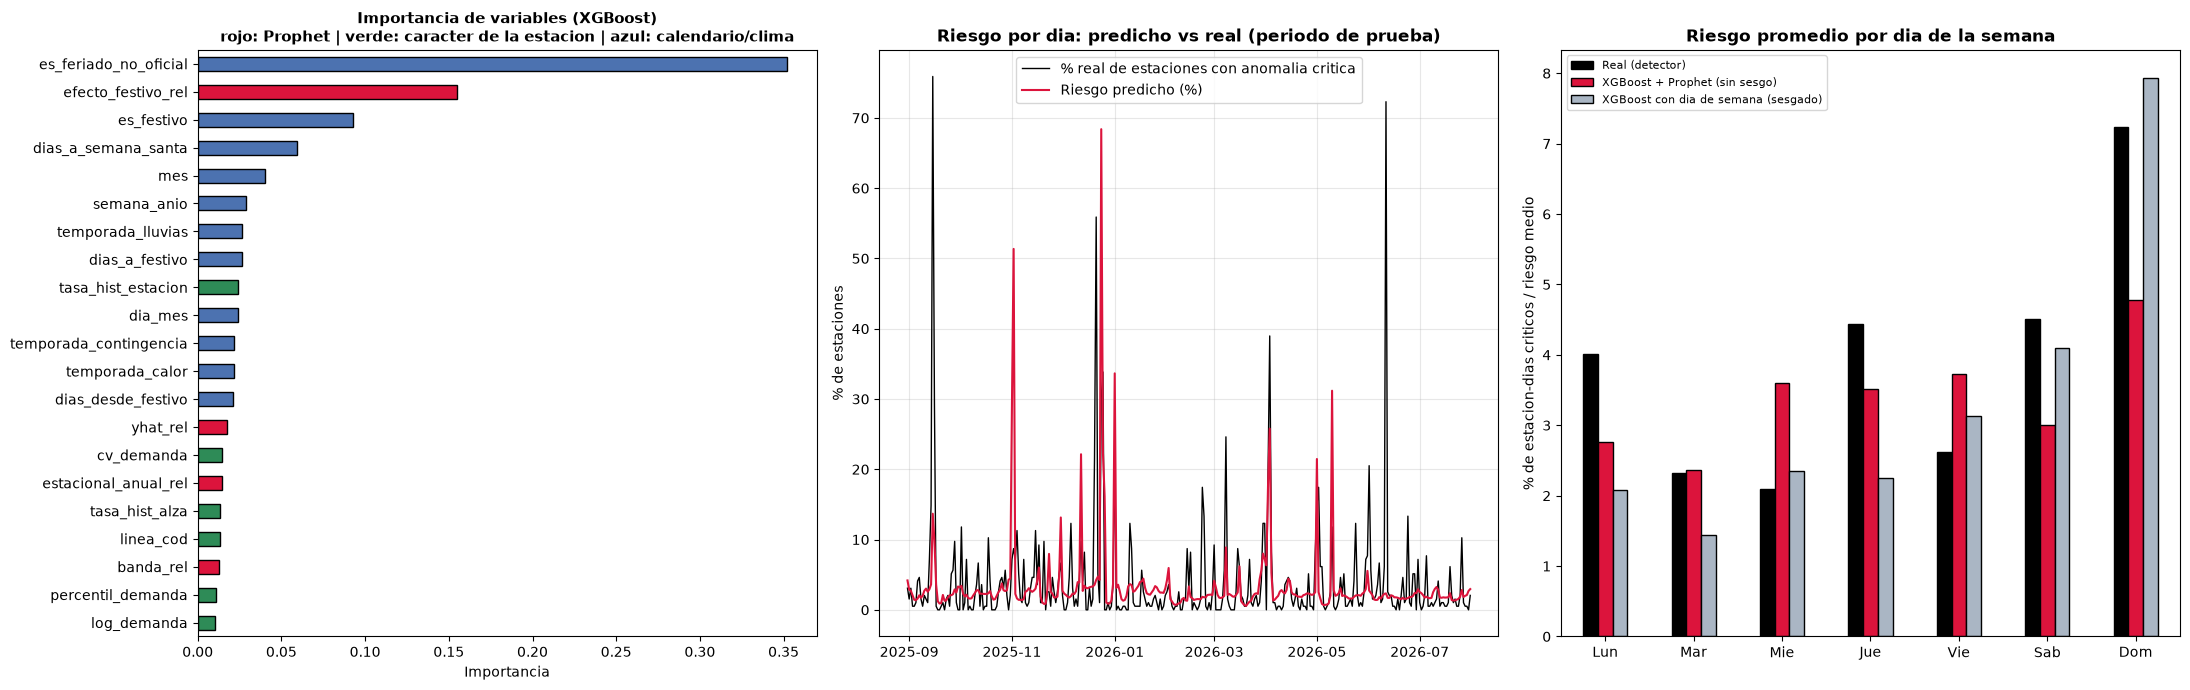

Correlacion de Spearman entre riesgo predicho y tasa real por dia calendario: 0.35
Domingo / entre semana -> real: 2.3x | modelo sin sesgo: 1.5x | modelo sesgado: 3.5x

Tasa historica de criticas por cuartil de demanda de la estacion (entrenamiento):
               tasa_hist_estacion  tasa_hist_alza
grupo_demanda                                    
Q1 baja                      2.89            1.26
Q2                           3.13            1.37
Q3                           3.19            1.24
Q4 alta                      3.66            1.47


In [26]:
# 6. Importancia de variables, comportamiento por dia y ausencia de sesgo de fin de semana (test)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

imp = pd.Series(modelos_ml[mejor_modelo].feature_importances_, index=FEATURES_ML).sort_values()
colores_imp = ['crimson' if f in FEATURES_PROPHET else ('seagreen' if f in FEATURES_ESTACION else '#4C72B0') for f in imp.index]
imp.plot(kind='barh', ax=ax1, color=colores_imp, edgecolor='black')
ax1.set_title(f'Importancia de variables ({mejor_modelo})\nrojo: Prophet | verde: caracter de la estacion | azul: calendario/clima',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Importancia')

# Riesgo promedio predicho por dia vs tasa real de criticas ese dia (todas las estaciones)
por_dia = (X_te.assign(riesgo=prob_te[mejor_modelo])
           .groupby('fecha').agg(riesgo_predicho=('riesgo', 'mean'), tasa_real=('es_critica', 'mean')))
ax2.plot(por_dia.index, por_dia['tasa_real'] * 100, color='black', linewidth=1, label='% real de estaciones con anomalia critica')
ax2.plot(por_dia.index, por_dia['riesgo_predicho'] * 100, color='crimson', linewidth=1.5, label='Riesgo predicho (%)')
ax2.set_title('Riesgo por dia: predicho vs real (periodo de prueba)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% de estaciones')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Riesgo por dia de la semana: real (sesgado hacia el fin de semana) vs predicho por cada modelo
por_dow = pd.DataFrame({
    'Real (detector)': y_te.groupby(X_te['dia_semana']).mean(),
    f'{mejor_modelo} + Prophet (sin sesgo)': pd.Series(prob_te[mejor_modelo], index=X_te.index).groupby(X_te['dia_semana']).mean(),
    f'{nom_sesgado} con dia de semana (sesgado)': pd.Series(prob_sesgado, index=X_te.index).groupby(X_te['dia_semana']).mean(),
}) * 100
por_dow.index = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
por_dow.plot(kind='bar', ax=ax3, color=['black', 'crimson', '#AAB6C4'], edgecolor='black')
ax3.set_title('Riesgo promedio por dia de la semana', fontsize=12, fontweight='bold')
ax3.set_ylabel('% de estacion-dias criticos / riesgo medio')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(fontsize=8)
plt.tight_layout()
plt.show()

corr_dia = por_dia.corr(method='spearman').iloc[0, 1]
print(f"Correlacion de Spearman entre riesgo predicho y tasa real por dia calendario: {corr_dia:.2f}")
print(f"Domingo / entre semana -> real: {por_dow.iloc[6, 0] / por_dow.iloc[:5, 0].mean():.1f}x | "
      f"modelo sin sesgo: {por_dow.iloc[6, 1] / por_dow.iloc[:5, 1].mean():.1f}x | "
      f"modelo sesgado: {por_dow.iloc[6, 2] / por_dow.iloc[:5, 2].mean():.1f}x")

# Caracter de la estacion: las de mayor demanda, tienen mas criticas al alza (sobrecarga)?
tabla_est = stats_tr.copy()
tabla_est['grupo_demanda'] = pd.qcut(tabla_est['percentil_demanda'], 4, labels=['Q1 baja', 'Q2', 'Q3', 'Q4 alta'])
print("\nTasa historica de criticas por cuartil de demanda de la estacion (entrenamiento):")
print((tabla_est.groupby('grupo_demanda', observed=True)[['tasa_hist_estacion', 'tasa_hist_alza']].mean() * 100).round(2).to_string())

Modelo: XGBoost + Prophet | horizonte: 2026-08-01 -> 2026-08-30 | estaciones: 195
Probabilidad base historica de anomalia critica: 3.35%

Top 15 estacion-dias con mayor riesgo (frente a un dia tipico del mismo dia de la semana):
     fecha dia_semana   linea         estacion  afluencia_esperada_prophet  yhat_lower  yhat_upper  prob_critica  riesgo_relativo  riesgo_vs_mismo_dia  ranking_en_el_dia
2026-08-23     Sunday linea 3          copilco                   22449.314   14201.715   30318.439         0.493           14.698               16.031                  1
2026-08-30     Sunday linea 3          copilco                   22221.249   14162.944   30808.646         0.433           12.904               14.075                  1
2026-08-09     Sunday linea b  villa de aragón                    2434.750       0.000    5316.812         0.379           11.290               12.315                  1
2026-08-23     Sunday linea a         guelatao                   14282.417   11477.569   17

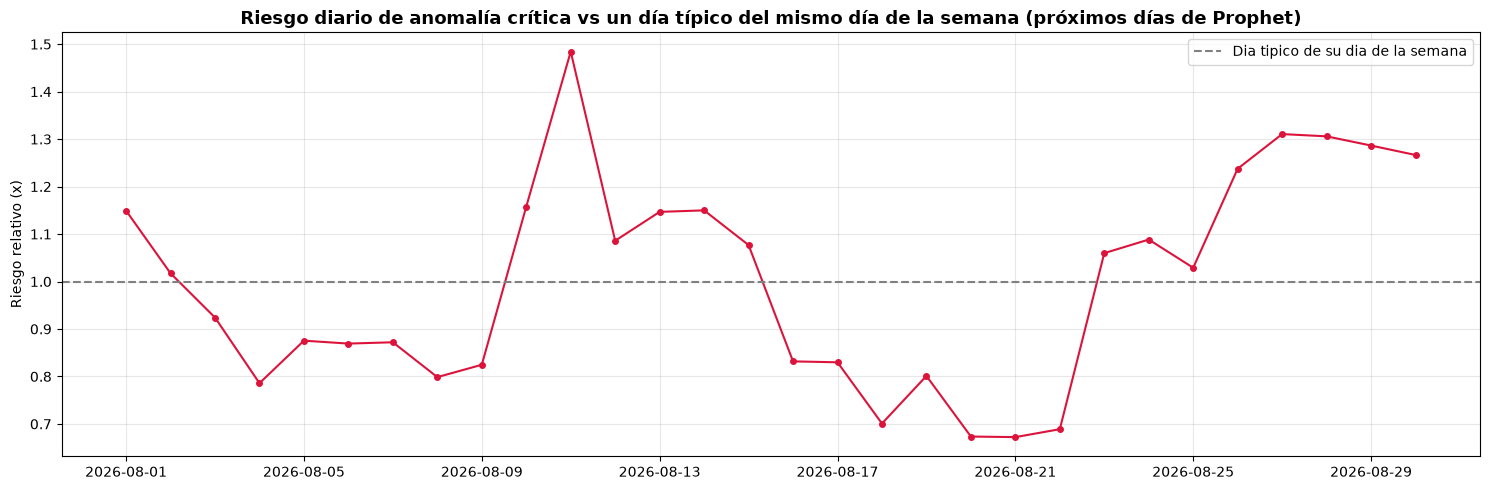

In [27]:
# 7. Propuesta: pronostico de Prophet + riesgo de anomalia critica para los proximos dias
# Reentrenar el mejor modelo (sin dia de la semana, balanceado por dia) con TODO el historico
stats_todo = stats_estacion(datos_ml)
tasa_global = datos_ml['es_critica'].mean()
X_todo = armar_matriz(datos_ml, stats_todo)
tasa_dia_todo = X_todo['es_critica'].groupby(X_todo['dia_semana']).mean()

modelo_final = crear_modelo(mejor_modelo).fit(
    X_todo[FEATURES_ML], X_todo['es_critica'],
    sample_weight=pesos_balance_dia(X_todo, X_todo['es_critica'], tasa_dia_todo, tasa_global))

# Dias futuros que pronostico Prophet, solo estaciones con datos en los ultimos 60 dias
ultima_fecha = datos_ml['fecha'].max()
activas = (datos_ml[datos_ml['fecha'] > ultima_fecha - pd.Timedelta(days=60)]
           [['linea', 'estacion']].drop_duplicates())
rejilla = futuro_ml.merge(activas, on=['linea', 'estacion'])

X_fut = armar_matriz(rejilla, stats_todo)
rejilla['prob_critica'] = modelo_final.predict_proba(X_fut[FEATURES_ML])[:, 1]
rejilla['riesgo_relativo'] = rejilla['prob_critica'] / tasa_global   # 1.0 = igual al promedio historico
rejilla['dia_semana'] = rejilla['fecha'].dt.day_name()
# Riesgo frente a un estacion-dia tipico del MISMO dia de la semana: neutro a fin de semana / entre semana.
# Es el criterio para ordenar la propuesta (un domingo solo sube si esta por encima de un domingo normal).
rejilla['riesgo_vs_mismo_dia'] = rejilla['prob_critica'] / rejilla.groupby('dia_semana')['prob_critica'].transform('mean')
rejilla['ranking_en_el_dia'] = rejilla.groupby('fecha')['riesgo_vs_mismo_dia'].rank(ascending=False, method='first').astype(int)

# El intervalo aditivo de Prophet puede salir negativo en estaciones de poca afluencia: se recorta a 0
rejilla['yhat_lower'] = rejilla['yhat_lower'].clip(lower=0)
propuesta = (rejilla.rename(columns={'yhat': 'afluencia_esperada_prophet'})
             .sort_values('riesgo_vs_mismo_dia', ascending=False)
             [['fecha', 'dia_semana', 'linea', 'estacion', 'afluencia_esperada_prophet', 'yhat_lower', 'yhat_upper',
               'prob_critica', 'riesgo_relativo', 'riesgo_vs_mismo_dia', 'ranking_en_el_dia']]
             .reset_index(drop=True))
propuesta.to_csv('propuesta_anomalias_futuras.csv', index=False)

print(f"Modelo: {mejor_modelo} + Prophet | horizonte: {rejilla['fecha'].min().date()} -> {rejilla['fecha'].max().date()} "
      f"| estaciones: {len(activas)}")
print(f"Probabilidad base historica de anomalia critica: {tasa_global*100:.2f}%\n")

print("Top 15 estacion-dias con mayor riesgo (frente a un dia tipico del mismo dia de la semana):")
print(propuesta.head(15).round(3).to_string(index=False))

riesgo_dia = rejilla.groupby('fecha')['prob_critica'].mean()
dow_dia = riesgo_dia.index.day_name()
riesgo_dia_rel = riesgo_dia / riesgo_dia.groupby(dow_dia).transform('mean')   # 1.0 = dia tipico de su dia de la semana

print("\nTop 10 dias con mayor riesgo frente a un dia tipico del mismo dia de la semana (todas las estaciones):")
print(pd.DataFrame({'dia': dow_dia, 'riesgo promedio (%)': (riesgo_dia * 100).round(2),
                    'vs mismo dia de semana (x)': riesgo_dia_rel.round(2)})
      .loc[riesgo_dia_rel.sort_values(ascending=False).head(10).index].to_string())

print("\nRiesgo medio por dia de la semana en el horizonte (sin sesgo fuerte de fin de semana):")
print((rejilla.groupby('dia_semana')['prob_critica'].mean() * 100).round(2).to_string())

plt.figure(figsize=(15, 5))
plt.plot(riesgo_dia_rel.index, riesgo_dia_rel.values, color='crimson', linewidth=1.5, marker='o', markersize=4)
plt.axhline(1, color='gray', linestyle='--', label='Dia tipico de su dia de la semana')
plt.title('Riesgo diario de anomalía crítica vs un día típico del mismo día de la semana (próximos días de Prophet)', fontsize=13, fontweight='bold')
plt.ylabel('Riesgo relativo (x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()